#### **Install these in command prompt before execution**

In [1]:
!pip install pandas
!pip install numpy==2.2.0 
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn 
!pip install missingno
!pip install umap-learn

  Using cached numpy-2.2.0-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.0-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.3
    Uninstalling numpy-2.1.3:
      Successfully uninstalled numpy-2.1.3


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.2.0 which is incompatible.


  Using cached numpy-2.1.3-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.1.3-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.0
    Uninstalling numpy-2.2.0:
      Successfully uninstalled numpy-2.2.0


#### **Load & Combine all Data**

In [2]:
import pandas as pd

# List of file paths and corresponding environment names
file_paths = [f'dataset/uwb_dataset_part{i}.csv' for i in range(1, 8)]
environments = ['Office 1', 'Office 2', 'Small Apartment', 
                'Small Workshop', 'Kitchen with a living room', 
                'Bedroom', 'Boiler room']

# Load each part into a list of DataFrames and add the 'Environment' column
data_parts = [pd.read_csv(file_path, header=0).assign(Environment=env) 
              for file_path, env in zip(file_paths, environments)]

# Combine all parts into a single DataFrame
combined_data_with_env = pd.concat(data_parts, ignore_index=True)

# Display the combined dataset with the new Environment feature
print(combined_data_with_env.head())
print(f"Combined dataset shape: {combined_data_with_env.shape}")

# Check rows per environment
print(combined_data_with_env['Environment'].value_counts())

# Check the number of rows in each part
for env, part in zip(environments, data_parts):
    print(f"{env} shape: {part.shape}")


   NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
0   0.0   3.90   745.0  18712.0  10250.0  11576.0         64.0  11855.0   
1   0.0   0.66   749.0  11239.0   6313.0   4712.0         64.0  18968.0   
2   1.0   7.86   746.0   4355.0   5240.0   3478.0         60.0  14699.0   
3   1.0   3.48   750.0   8502.0   8416.0   5890.0         76.0   8748.0   
4   0.0   1.19   746.0  17845.0  18095.0  12058.0         68.0  11380.0   

   MAX_NOISE  RXPACC  ...  CIR1007  CIR1008  CIR1009  CIR1010  CIR1011  \
0      967.0   611.0  ...    458.0    183.0    158.0    198.0     87.0   
1     1133.0   447.0  ...    334.0    290.0    228.0    187.0    213.0   
2      894.0   723.0  ...    373.0    224.0    174.0    124.0    329.0   
3     1127.0  1024.0  ...    173.0    198.0    160.0    434.0    397.0   
4     1744.0   276.0  ...    209.0    242.0    296.0     87.0    178.0   

   CIR1012  CIR1013  CIR1014  CIR1015  Environment  
0    296.0    505.0    307.0      0.0     Office 1 

In [3]:
# Check the number of rows in each part
for i, part in enumerate(data_parts, start=1):
    print(f"Part {i} shape: {part.shape}")

# Check the combined dataset
print(f"Combined dataset shape: {combined_data_with_env.shape}")
print(combined_data_with_env.head())

Part 1 shape: (6000, 1032)
Part 2 shape: (6000, 1032)
Part 3 shape: (6000, 1032)
Part 4 shape: (6000, 1032)
Part 5 shape: (6000, 1032)
Part 6 shape: (6000, 1032)
Part 7 shape: (6000, 1032)
Combined dataset shape: (42000, 1032)
   NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
0   0.0   3.90   745.0  18712.0  10250.0  11576.0         64.0  11855.0   
1   0.0   0.66   749.0  11239.0   6313.0   4712.0         64.0  18968.0   
2   1.0   7.86   746.0   4355.0   5240.0   3478.0         60.0  14699.0   
3   1.0   3.48   750.0   8502.0   8416.0   5890.0         76.0   8748.0   
4   0.0   1.19   746.0  17845.0  18095.0  12058.0         68.0  11380.0   

   MAX_NOISE  RXPACC  ...  CIR1007  CIR1008  CIR1009  CIR1010  CIR1011  \
0      967.0   611.0  ...    458.0    183.0    158.0    198.0     87.0   
1     1133.0   447.0  ...    334.0    290.0    228.0    187.0    213.0   
2      894.0   723.0  ...    373.0    224.0    174.0    124.0    329.0   
3     1127.0  1024.0  ... 

In [4]:
# To display all column names
print(combined_data_with_env.columns.tolist())

['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'CH', 'FRAME_LEN', 'PREAM_LEN', 'BITRATE', 'PRFR', 'CIR0', 'CIR1', 'CIR2', 'CIR3', 'CIR4', 'CIR5', 'CIR6', 'CIR7', 'CIR8', 'CIR9', 'CIR10', 'CIR11', 'CIR12', 'CIR13', 'CIR14', 'CIR15', 'CIR16', 'CIR17', 'CIR18', 'CIR19', 'CIR20', 'CIR21', 'CIR22', 'CIR23', 'CIR24', 'CIR25', 'CIR26', 'CIR27', 'CIR28', 'CIR29', 'CIR30', 'CIR31', 'CIR32', 'CIR33', 'CIR34', 'CIR35', 'CIR36', 'CIR37', 'CIR38', 'CIR39', 'CIR40', 'CIR41', 'CIR42', 'CIR43', 'CIR44', 'CIR45', 'CIR46', 'CIR47', 'CIR48', 'CIR49', 'CIR50', 'CIR51', 'CIR52', 'CIR53', 'CIR54', 'CIR55', 'CIR56', 'CIR57', 'CIR58', 'CIR59', 'CIR60', 'CIR61', 'CIR62', 'CIR63', 'CIR64', 'CIR65', 'CIR66', 'CIR67', 'CIR68', 'CIR69', 'CIR70', 'CIR71', 'CIR72', 'CIR73', 'CIR74', 'CIR75', 'CIR76', 'CIR77', 'CIR78', 'CIR79', 'CIR80', 'CIR81', 'CIR82', 'CIR83', 'CIR84', 'CIR85', 'CIR86', 'CIR87', 'CIR88', 'CIR89', 'CIR90', 'CIR91', 'CIR92', 'CIR93', 'CI

#### **Dataset Verification**

In [5]:
# 1. Verify total number of samples
print("\n=== DATA INTEGRITY CHECK ===")
print(f"Total number of samples: {combined_data_with_env.shape[0]}")
print(f"Expected samples: 42,000")
if combined_data_with_env.shape[0] == 42000:
    print("✅ Sample count matches expected total")
else:
    print(f"❌ Sample count mismatch. Found {combined_data_with_env.shape[0]} instead of 42,000")


=== DATA INTEGRITY CHECK ===
Total number of samples: 42000
Expected samples: 42,000
✅ Sample count matches expected total


In [6]:
# 2. Check class balance
class_counts = combined_data_with_env['NLOS'].value_counts()
print("\n=== CLASS BALANCE CHECK ===")
print(class_counts)
print(f"LOS percentage: {class_counts.get(0, 0) / combined_data_with_env.shape[0] * 100:.2f}%")
print(f"NLOS percentage: {class_counts.get(1, 0) / combined_data_with_env.shape[0] * 100:.2f}%")

if abs(class_counts.get(0, 0) - class_counts.get(1, 0)) < combined_data_with_env.shape[0] * 0.01:
    print("✅ Class balance is approximately 50/50")
else:
    print("❌ Class imbalance detected")


=== CLASS BALANCE CHECK ===
NLOS
0.0    21000
1.0    21000
Name: count, dtype: int64
LOS percentage: 50.00%
NLOS percentage: 50.00%
✅ Class balance is approximately 50/50


In [7]:
# 4. Check data formatting (sample check)
print("\n=== DATA FORMAT CHECK ===")
print("Data types:")
print(combined_data_with_env.dtypes)


=== DATA FORMAT CHECK ===
Data types:
NLOS           float64
RANGE          float64
FP_IDX         float64
FP_AMP1        float64
FP_AMP2        float64
                ...   
CIR1012        float64
CIR1013        float64
CIR1014        float64
CIR1015        float64
Environment     object
Length: 1032, dtype: object


In [8]:
# 5. Check environment distribution
print("\n=== ENVIRONMENT DISTRIBUTION ===")
env_counts = combined_data_with_env['Environment'].value_counts()
print(env_counts)

# Each environment should have 6,000 samples (3,000 LOS + 3,000 NLOS)
env_balanced = True
for env, count in env_counts.items():
    if count != 6000:
        print(f"❌ Environment '{env}' has {count} samples instead of expected 6,000")
        env_balanced = False

if env_balanced:
    print("✅ All environments have the expected 6,000 samples")


=== ENVIRONMENT DISTRIBUTION ===
Environment
Office 1                      6000
Office 2                      6000
Small Apartment               6000
Small Workshop                6000
Kitchen with a living room    6000
Bedroom                       6000
Boiler room                   6000
Name: count, dtype: int64
✅ All environments have the expected 6,000 samples


Data types of CIR columns:
CIR0       float64
CIR1       float64
CIR2       float64
CIR3       float64
CIR4       float64
            ...   
CIR1011    float64
CIR1012    float64
CIR1013    float64
CIR1014    float64
CIR1015    float64
Length: 1016, dtype: object
Number of CIR columns: 1016
First few CIR values:
CIR0    129.0
CIR1    312.0
CIR2    331.0
CIR3    141.0
CIR4    160.0
Name: 0, dtype: object
Last few CIR values:
CIR1011     87.0
CIR1012    296.0
CIR1013    505.0
CIR1014    307.0
CIR1015      0.0
Name: 0, dtype: object
Missing values in CIR columns:
Series([], dtype: int64)


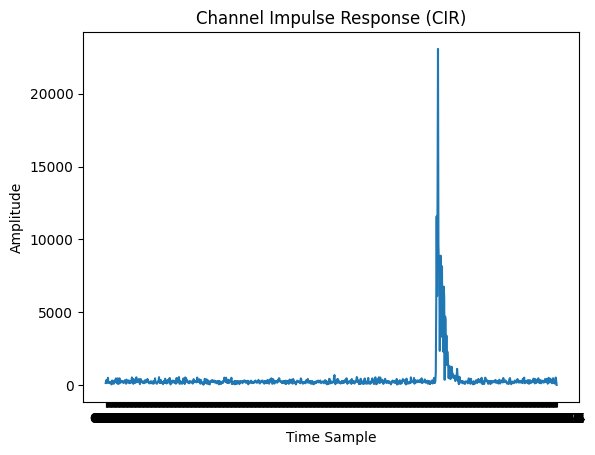

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming combined_data_with_env is your DataFrame
# List of CIR columns
cir_columns = [f'CIR{i}' for i in range(1016)]

# 1. Check data types of CIR columns
print("Data types of CIR columns:")
print(combined_data_with_env[cir_columns].dtypes)

# 2. Verify the shape of CIR data
print(f"Number of CIR columns: {len(cir_columns)}")

# 3. Inspect a sample row
sample_cir = combined_data_with_env.loc[0, cir_columns]
print("First few CIR values:")
print(sample_cir.head())
print("Last few CIR values:")
print(sample_cir.tail())

# 4. Check for missing values
missing_values = combined_data_with_env[cir_columns].isnull().sum()
print("Missing values in CIR columns:")
print(missing_values[missing_values > 0])

# 5. Visualize the CIR
plt.plot(sample_cir)
plt.title("Channel Impulse Response (CIR)")
plt.xlabel("Time Sample")
plt.ylabel("Amplitude")
plt.show()

#### **Data Cleaning [Part 1]**

#### **Check for null value**

In [10]:
# Find columns with missing values
missing_values = combined_data_with_env.isnull().sum()
missing_cols = missing_values[missing_values > 0]
print("Columns with missing values:")
if not missing_cols.empty:
    print(missing_cols)
else:
    print("No missing values found.")

Columns with missing values:
No missing values found.


#### **Check for duplicate value**

In [11]:
# duplicate rows count
duplicate_rows = combined_data_with_env.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# print duplicate rows if they exist
if duplicate_rows > 0:
    print("Sample duplicate rows:")
    print(combined_data[combined_data_with_env.duplicated()].head())

Number of duplicate rows: 0


### **Baseline DF = combined_data_with_env**

#### **One-Hot Encoding Enviroment Feature**

In [12]:
env_encoded = pd.get_dummies(combined_data_with_env['Environment'], prefix='Env')
combined_data_with_encoding = pd.concat([combined_data_with_env, env_encoded], axis=1)

In [13]:
combined_data_with_encoding.head()

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR1014,CIR1015,Environment,Env_Bedroom,Env_Boiler room,Env_Kitchen with a living room,Env_Office 1,Env_Office 2,Env_Small Apartment,Env_Small Workshop
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,307.0,0.0,Office 1,False,False,False,True,False,False,False
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,103.0,0.0,Office 1,False,False,False,True,False,False,False
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,218.0,0.0,Office 1,False,False,False,True,False,False,False
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,342.0,256.0,Office 1,False,False,False,True,False,False,False
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,292.0,256.0,Office 1,False,False,False,True,False,False,False


In [14]:
print(combined_data_with_encoding.columns.tolist())

['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'CH', 'FRAME_LEN', 'PREAM_LEN', 'BITRATE', 'PRFR', 'CIR0', 'CIR1', 'CIR2', 'CIR3', 'CIR4', 'CIR5', 'CIR6', 'CIR7', 'CIR8', 'CIR9', 'CIR10', 'CIR11', 'CIR12', 'CIR13', 'CIR14', 'CIR15', 'CIR16', 'CIR17', 'CIR18', 'CIR19', 'CIR20', 'CIR21', 'CIR22', 'CIR23', 'CIR24', 'CIR25', 'CIR26', 'CIR27', 'CIR28', 'CIR29', 'CIR30', 'CIR31', 'CIR32', 'CIR33', 'CIR34', 'CIR35', 'CIR36', 'CIR37', 'CIR38', 'CIR39', 'CIR40', 'CIR41', 'CIR42', 'CIR43', 'CIR44', 'CIR45', 'CIR46', 'CIR47', 'CIR48', 'CIR49', 'CIR50', 'CIR51', 'CIR52', 'CIR53', 'CIR54', 'CIR55', 'CIR56', 'CIR57', 'CIR58', 'CIR59', 'CIR60', 'CIR61', 'CIR62', 'CIR63', 'CIR64', 'CIR65', 'CIR66', 'CIR67', 'CIR68', 'CIR69', 'CIR70', 'CIR71', 'CIR72', 'CIR73', 'CIR74', 'CIR75', 'CIR76', 'CIR77', 'CIR78', 'CIR79', 'CIR80', 'CIR81', 'CIR82', 'CIR83', 'CIR84', 'CIR85', 'CIR86', 'CIR87', 'CIR88', 'CIR89', 'CIR90', 'CIR91', 'CIR92', 'CIR93', 'CI

#### **Data Feature Extraction (FP VALUES)**

In [15]:
import numpy as np
import pandas as pd
# Feature extraction methods

# 1. Basic stats
combined_data_with_encoding['FP_AMP_mean'] = combined_data_with_encoding[['FP_AMP1', 'FP_AMP2', 'FP_AMP3']].mean(axis=1)
combined_data_with_encoding['FP_AMP_std'] = combined_data_with_encoding[['FP_AMP1', 'FP_AMP2', 'FP_AMP3']].std(axis=1)
combined_data_with_encoding['FP_AMP_max'] = combined_data_with_encoding[['FP_AMP1', 'FP_AMP2', 'FP_AMP3']].max(axis=1)
combined_data_with_encoding['FP_AMP_min'] = combined_data_with_encoding[['FP_AMP1', 'FP_AMP2', 'FP_AMP3']].min(axis=1)
combined_data_with_encoding['FP_AMP_range'] = combined_data_with_encoding['FP_AMP_max'] - combined_data_with_encoding['FP_AMP_min']

# 2. Power-based feature
A = 121.74  # Based on your manual for First Path Power Level
combined_data_with_encoding['FP_POWER'] = 10 * np.log10(
    (combined_data_with_encoding['FP_AMP1']**2 + combined_data_with_encoding['FP_AMP2']**2 + combined_data_with_encoding['FP_AMP3']**2) / (combined_data_with_encoding['RXPACC']**2)
) - A

# 3. Ratios between FP Amplitudes
combined_data_with_encoding['FP_AMP1_ratio'] = combined_data_with_encoding['FP_AMP1'] / combined_data_with_encoding['FP_AMP2']
combined_data_with_encoding['FP_AMP2_ratio'] = combined_data_with_encoding['FP_AMP2'] / combined_data_with_encoding['FP_AMP3']
combined_data_with_encoding['FP_AMP3_ratio'] = combined_data_with_encoding['FP_AMP3'] / combined_data_with_encoding['FP_AMP1']


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Define a function to train and evaluate models
def evaluate_model(features, target, model):
    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    return mae, r2


In [17]:
# Target variable
y = combined_data_with_encoding['FP_POWER']

# Feature combinations for testing
feature_sets = {
    "Raw Amplitudes": combined_data_with_encoding[['FP_AMP1', 'FP_AMP2', 'FP_AMP3']],
    "Basic Stats": combined_data_with_encoding[['FP_AMP_mean', 'FP_AMP_std', 'FP_AMP_max', 'FP_AMP_min', 'FP_AMP_range']],
    "Power-based": combined_data_with_encoding[['FP_POWER']],
    "Ratios": combined_data_with_encoding[['FP_AMP1_ratio', 'FP_AMP2_ratio', 'FP_AMP3_ratio']],
    "Combined": combined_data_with_encoding[['FP_AMP_mean', 'FP_AMP_std', 'FP_AMP_range', 'FP_AMP1_ratio', 'FP_AMP2_ratio', 'FP_AMP3_ratio', 'FP_POWER']]
}

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Compare performance
results = {}

for model_name, model in models.items():
    print(f"\nModel: {model_name}")
    results[model_name] = {}
    
    for feature_name, features in feature_sets.items():
        mae, r2 = evaluate_model(features, y, model)
        results[model_name][feature_name] = {"MAE": mae, "R-squared": r2}
        print(f"{feature_name} -> MAE: {mae:.4f}, R-squared: {r2:.4f}")



Model: Linear Regression
Raw Amplitudes -> MAE: 3.1083, R-squared: 0.8344
Basic Stats -> MAE: 2.9182, R-squared: 0.8520
Power-based -> MAE: 0.0000, R-squared: 1.0000
Ratios -> MAE: 8.2300, R-squared: 0.0109
Combined -> MAE: 0.0000, R-squared: 1.0000

Model: Random Forest
Raw Amplitudes -> MAE: 2.6606, R-squared: 0.8753
Basic Stats -> MAE: 2.7287, R-squared: 0.8710
Power-based -> MAE: 0.0006, R-squared: 1.0000
Ratios -> MAE: 8.1409, R-squared: -0.0607
Combined -> MAE: 0.0010, R-squared: 1.0000


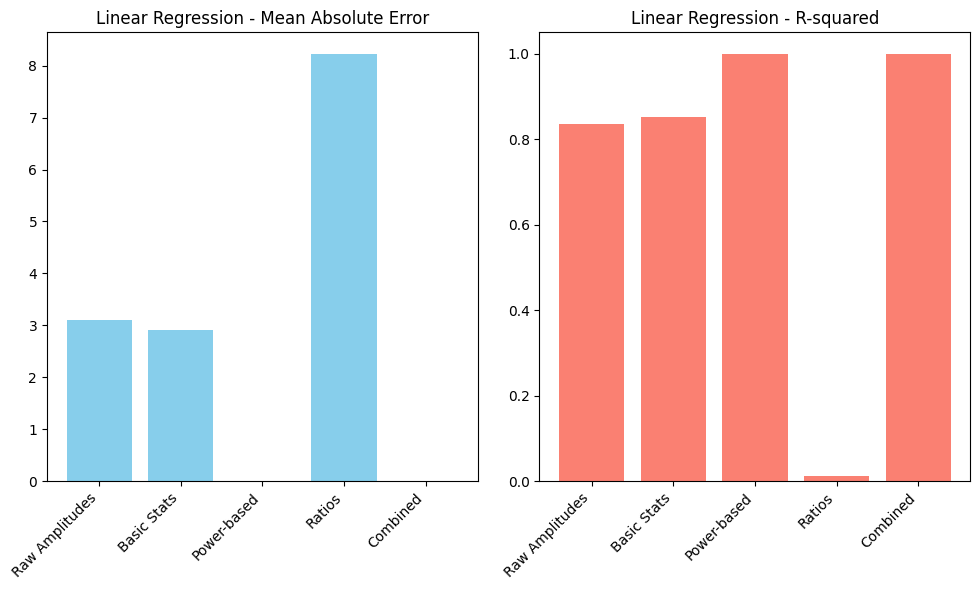

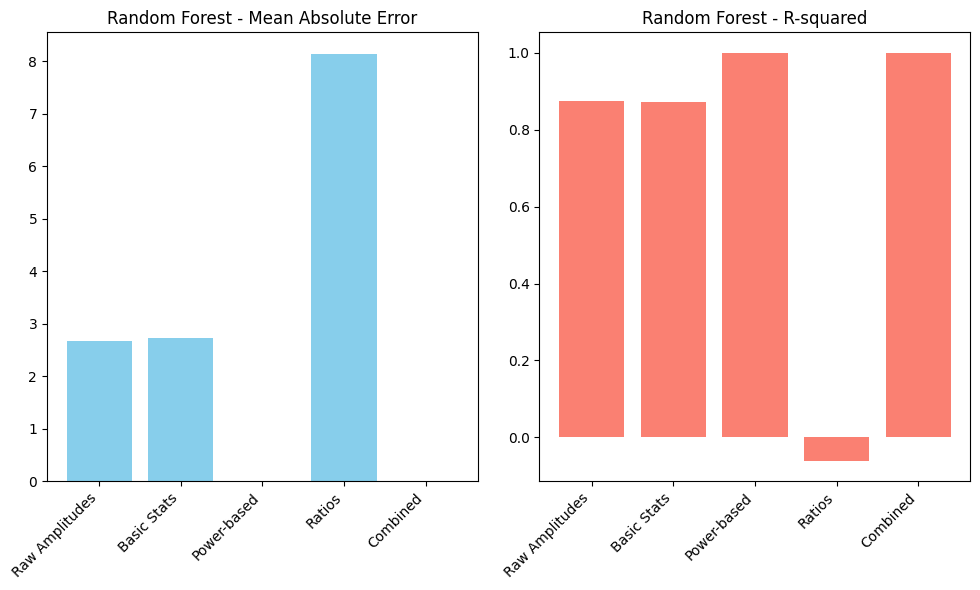

In [18]:
import matplotlib.pyplot as plt

# Visualization
for model_name, model_results in results.items():
    plt.figure(figsize=(10, 6))
    feature_names = list(model_results.keys())
    mae_scores = [model_results[feat]["MAE"] for feat in feature_names]
    r2_scores = [model_results[feat]["R-squared"] for feat in feature_names]
    
    # MAE plot
    plt.subplot(1, 2, 1)
    plt.bar(feature_names, mae_scores, color='skyblue')
    plt.title(f'{model_name} - Mean Absolute Error')
    plt.xticks(rotation=45, ha="right")
    
    # R-squared plot
    plt.subplot(1, 2, 2)
    plt.bar(feature_names, r2_scores, color='salmon')
    plt.title(f'{model_name} - R-squared')
    plt.xticks(rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()


In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from itertools import combinations

# Raw values
combined_data_with_encoding['FP_Mean'] = combined_data_with_encoding[['FP_AMP1', 'FP_AMP2', 'FP_AMP3']].mean(axis=1)
combined_data_with_encoding['FP_Range'] = combined_data_with_encoding[['FP_AMP1', 'FP_AMP2', 'FP_AMP3']].max(axis=1) - combined_data_with_encoding[['FP_AMP1', 'FP_AMP2', 'FP_AMP3']].min(axis=1)

# Avoid divide by zero errors for ratios
combined_data_with_encoding['FP_Ratio_12'] = combined_data_with_encoding['FP_AMP1'] / (combined_data_with_encoding['FP_AMP2'] + 1e-9)
combined_data_with_encoding['FP_Ratio_13'] = combined_data_with_encoding['FP_AMP1'] / (combined_data_with_encoding['FP_AMP3'] + 1e-9)
combined_data_with_encoding['FP_Ratio_23'] = combined_data_with_encoding['FP_AMP2'] / (combined_data_with_encoding['FP_AMP3'] + 1e-9)

# 2. Power-based feature
A = 121.74  # Based on your manual for First Path Power Level
combined_data_with_encoding['FP_POWER'] = 10 * np.log10(
    (combined_data_with_encoding['FP_AMP1']**2 + combined_data_with_encoding['FP_AMP2']**2 + combined_data_with_encoding['FP_AMP3']**2) / (combined_data_with_encoding['RXPACC']**2)
) - A


# Feature sets for comparison
feature_sets = {
    "Raw": ['FP_AMP1', 'FP_AMP2', 'FP_AMP3'],
    "Mean_Range": ['FP_Mean', 'FP_Range'],
    "Ratios": ['FP_Ratio_12', 'FP_Ratio_13', 'FP_Ratio_23'],
    "Power-based": ['FP_POWER']
}

# Generate all possible combinations of feature sets
all_combinations = {}
for r in range(1, len(feature_sets) + 1):
    for combo in combinations(feature_sets.keys(), r):
        combo_name = "+".join(combo)
        combo_features = []
        for feature_set in combo:
            combo_features.extend(feature_sets[feature_set])
        all_combinations[combo_name] = combo_features

# Add individual feature sets to the combinations
all_combinations.update(feature_sets)

# Target variable
target = combined_data_with_encoding['NLOS']


In [20]:
# Store accuracy scores
results = {}

# Iterate through all combinations
for name, features in all_combinations.items():
    X = combined_data_with_encoding[features]
    X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.3, random_state=42)

    # Train Random Forest
    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_classifier.fit(X_train, y_train)

    # Predictions and accuracy
    y_pred = rf_classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

# Display results
print("Model accuracy for different feature extraction methods and combinations:")
for method, acc in results.items():
    print(f"{method}: {acc:.4f}")

Model accuracy for different feature extraction methods and combinations:
Raw: 0.7522
Mean_Range: 0.7248
Ratios: 0.5284
Power-based: 0.7579
Raw+Mean_Range: 0.7503
Raw+Ratios: 0.7488
Raw+Power-based: 0.8502
Mean_Range+Ratios: 0.7512
Mean_Range+Power-based: 0.8463
Ratios+Power-based: 0.8305
Raw+Mean_Range+Ratios: 0.7491
Raw+Mean_Range+Power-based: 0.8476
Raw+Ratios+Power-based: 0.8490
Mean_Range+Ratios+Power-based: 0.8496
Raw+Mean_Range+Ratios+Power-based: 0.8483


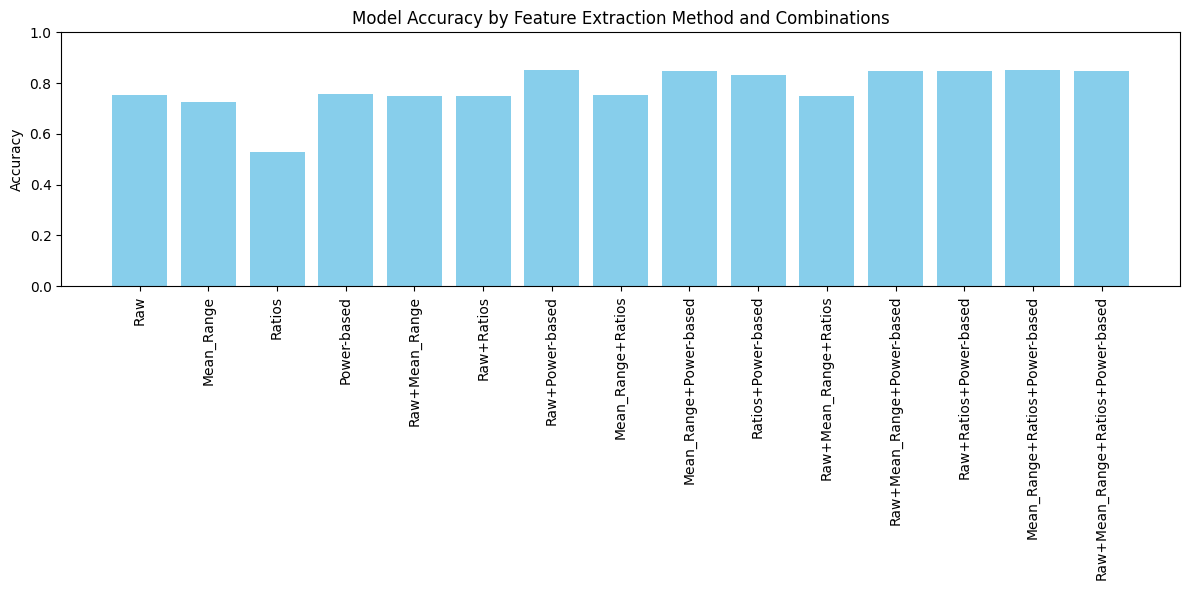

In [21]:
# Visualize results
plt.figure(figsize=(12, 6))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.title('Model Accuracy by Feature Extraction Method and Combinations')
plt.ylabel('Accuracy')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.ylim(0, 1)  # Set y-axis limit to 0-1 for accuracy
plt.tight_layout()  # Adjust layout to prevent label overlap
plt.show()

In [22]:
#keep only the FP-POWER
# List of columns to remove (all except FP_POWER)
columns_to_remove = [
    'FP_AMP_mean', 'FP_AMP_std', 'FP_AMP_max', 'FP_AMP_min', 'FP_AMP_range',
    'FP_AMP1_ratio', 'FP_AMP2_ratio', 'FP_AMP3_ratio', 'FP_Mean', 'FP_Range',
    'FP_Ratio_12', 'FP_Ratio_13', 'FP_Ratio_23'
]

# Drop the unnecessary columns
combined_data_with_encoding = combined_data_with_encoding.drop(columns=columns_to_remove)

# Display the updated DataFrame
print(combined_data_with_encoding.head())


   NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
0   0.0   3.90   745.0  18712.0  10250.0  11576.0         64.0  11855.0   
1   0.0   0.66   749.0  11239.0   6313.0   4712.0         64.0  18968.0   
2   1.0   7.86   746.0   4355.0   5240.0   3478.0         60.0  14699.0   
3   1.0   3.48   750.0   8502.0   8416.0   5890.0         76.0   8748.0   
4   0.0   1.19   746.0  17845.0  18095.0  12058.0         68.0  11380.0   

   MAX_NOISE  RXPACC  ...  CIR1015  Environment  Env_Bedroom  Env_Boiler room  \
0      967.0   611.0  ...      0.0     Office 1        False            False   
1     1133.0   447.0  ...      0.0     Office 1        False            False   
2      894.0   723.0  ...      0.0     Office 1        False            False   
3     1127.0  1024.0  ...    256.0     Office 1        False            False   
4     1744.0   276.0  ...    256.0     Office 1        False            False   

   Env_Kitchen with a living room  Env_Office 1  Env_Office 2 

#### **Data Feature Extraction (PCA CIR READINGS)**

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import PolynomialFeatures

In [24]:
#Check whether if CIR_value is linear or non-linear
# Extract columns CIR0 to CIR1015 (adjusted range)
pca_data = combined_data_with_encoding.loc[:, 'CIR0':'CIR1015'].copy()  # Select columns CIR0 to CIR1015
target = combined_data_with_encoding['NLOS']  # Target variable (NLOS)

# Step 2: Check linear correlation between features and target
correlation_with_target = pca_data.corrwith(target)
print("Correlation with target (NLOS):")
print(correlation_with_target)

Correlation with target (NLOS):
CIR0       0.204386
CIR1       0.181933
CIR2       0.133125
CIR3       0.177418
CIR4       0.099459
             ...   
CIR1011    0.183408
CIR1012    0.095495
CIR1013    0.182948
CIR1014    0.229277
CIR1015    0.092241
Length: 1016, dtype: float64


Correlation with target (NLOS) for non-CIR features (including CIR_PWR):
RANGE          0.456845
FP_IDX        -0.316978
FP_AMP1       -0.447279
FP_AMP2       -0.524905
FP_AMP3       -0.514339
STDEV_NOISE    0.152291
CIR_PWR       -0.392303
MAX_NOISE     -0.198198
RXPACC         0.730690
CH                  NaN
FRAME_LEN      0.034316
PREAM_LEN      0.189658
BITRATE             NaN
PRFR                NaN
FP_POWER      -0.694656
dtype: float64


C:\Users\Leong Jing Feng\anaconda3\envs\DA_Project\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Leong Jing Feng\anaconda3\envs\DA_Project\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


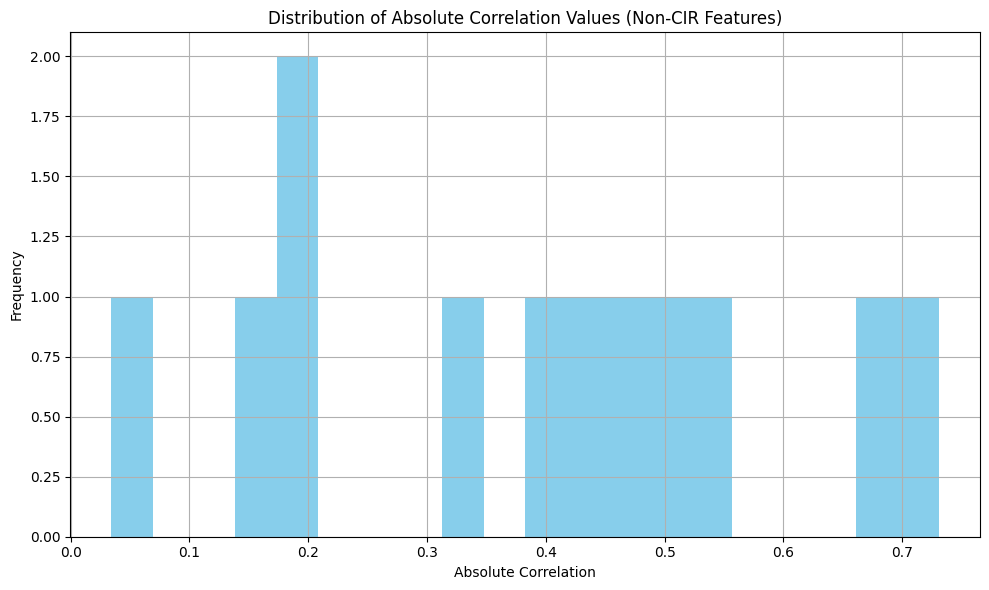

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract non-CIR features (including CIR_PWR but excluding CIR0 to CIR1015)
non_cir_features = combined_data_with_encoding.drop(columns=[col for col in combined_data_with_encoding.columns if col.startswith('CIR') and col != 'CIR_PWR'])

# Ensure only numeric features are considered
numeric_features = non_cir_features.select_dtypes(include=['float64', 'int64'])

# Remove target column from features
features_without_target = numeric_features.drop(columns=['NLOS'], errors='ignore')

# Calculate correlation with target (NLOS)
correlation_with_target_non_cir = features_without_target.corrwith(target)
print("Correlation with target (NLOS) for non-CIR features (including CIR_PWR):")
print(correlation_with_target_non_cir)

# Plot histogram of absolute correlation values
plt.figure(figsize=(10, 6))
plt.hist(correlation_with_target_non_cir.abs(), bins=20, color='skyblue')
plt.title('Distribution of Absolute Correlation Values (Non-CIR Features)')
plt.xlabel('Absolute Correlation')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

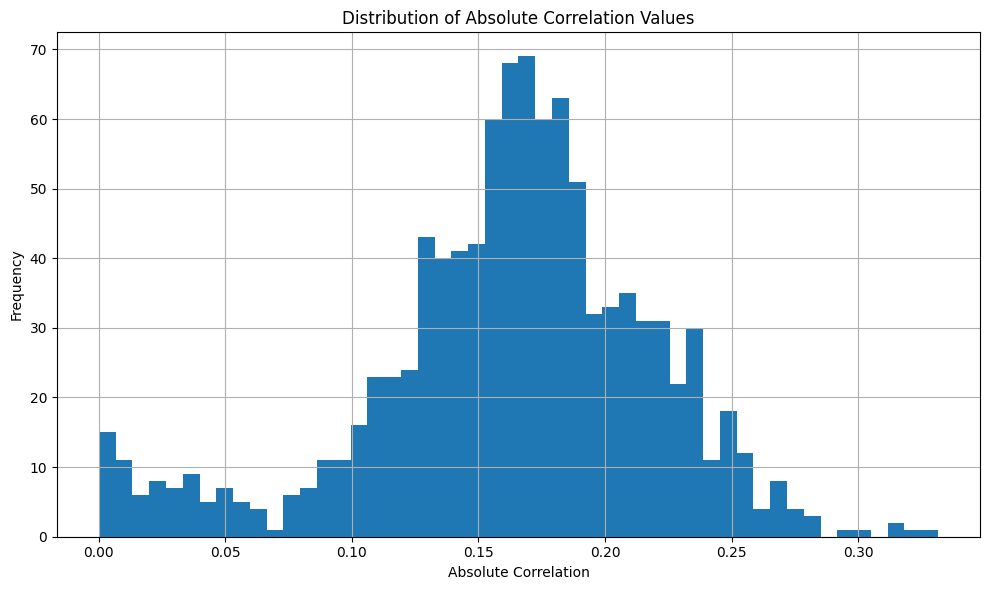

In [26]:
# Step 4: Plot histogram of correlation values
plt.figure(figsize=(10, 6))
plt.hist(correlation_with_target.abs(), bins=50)
plt.title('Distribution of Absolute Correlation Values')
plt.xlabel('Absolute Correlation')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.savefig('correlation_histogram.png')
plt.show()

In [27]:
# Step 5: Identify features with highest correlation
top_corr_features = correlation_with_target.abs().nlargest(10)
print("Top 10 features with highest correlation to NLOS:")
print(top_corr_features)

Top 10 features with highest correlation to NLOS:
CIR751    0.331593
CIR742    0.318422
CIR741    0.317597
CIR752    0.316465
CIR750    0.300113
CIR574    0.297642
CIR582    0.279876
CIR753    0.279043
CIR326    0.278957
CIR575    0.276699
dtype: float64


In [28]:
#Extract the feature names (column names) from the top correlations
top_feature_names = top_corr_features.index.tolist()

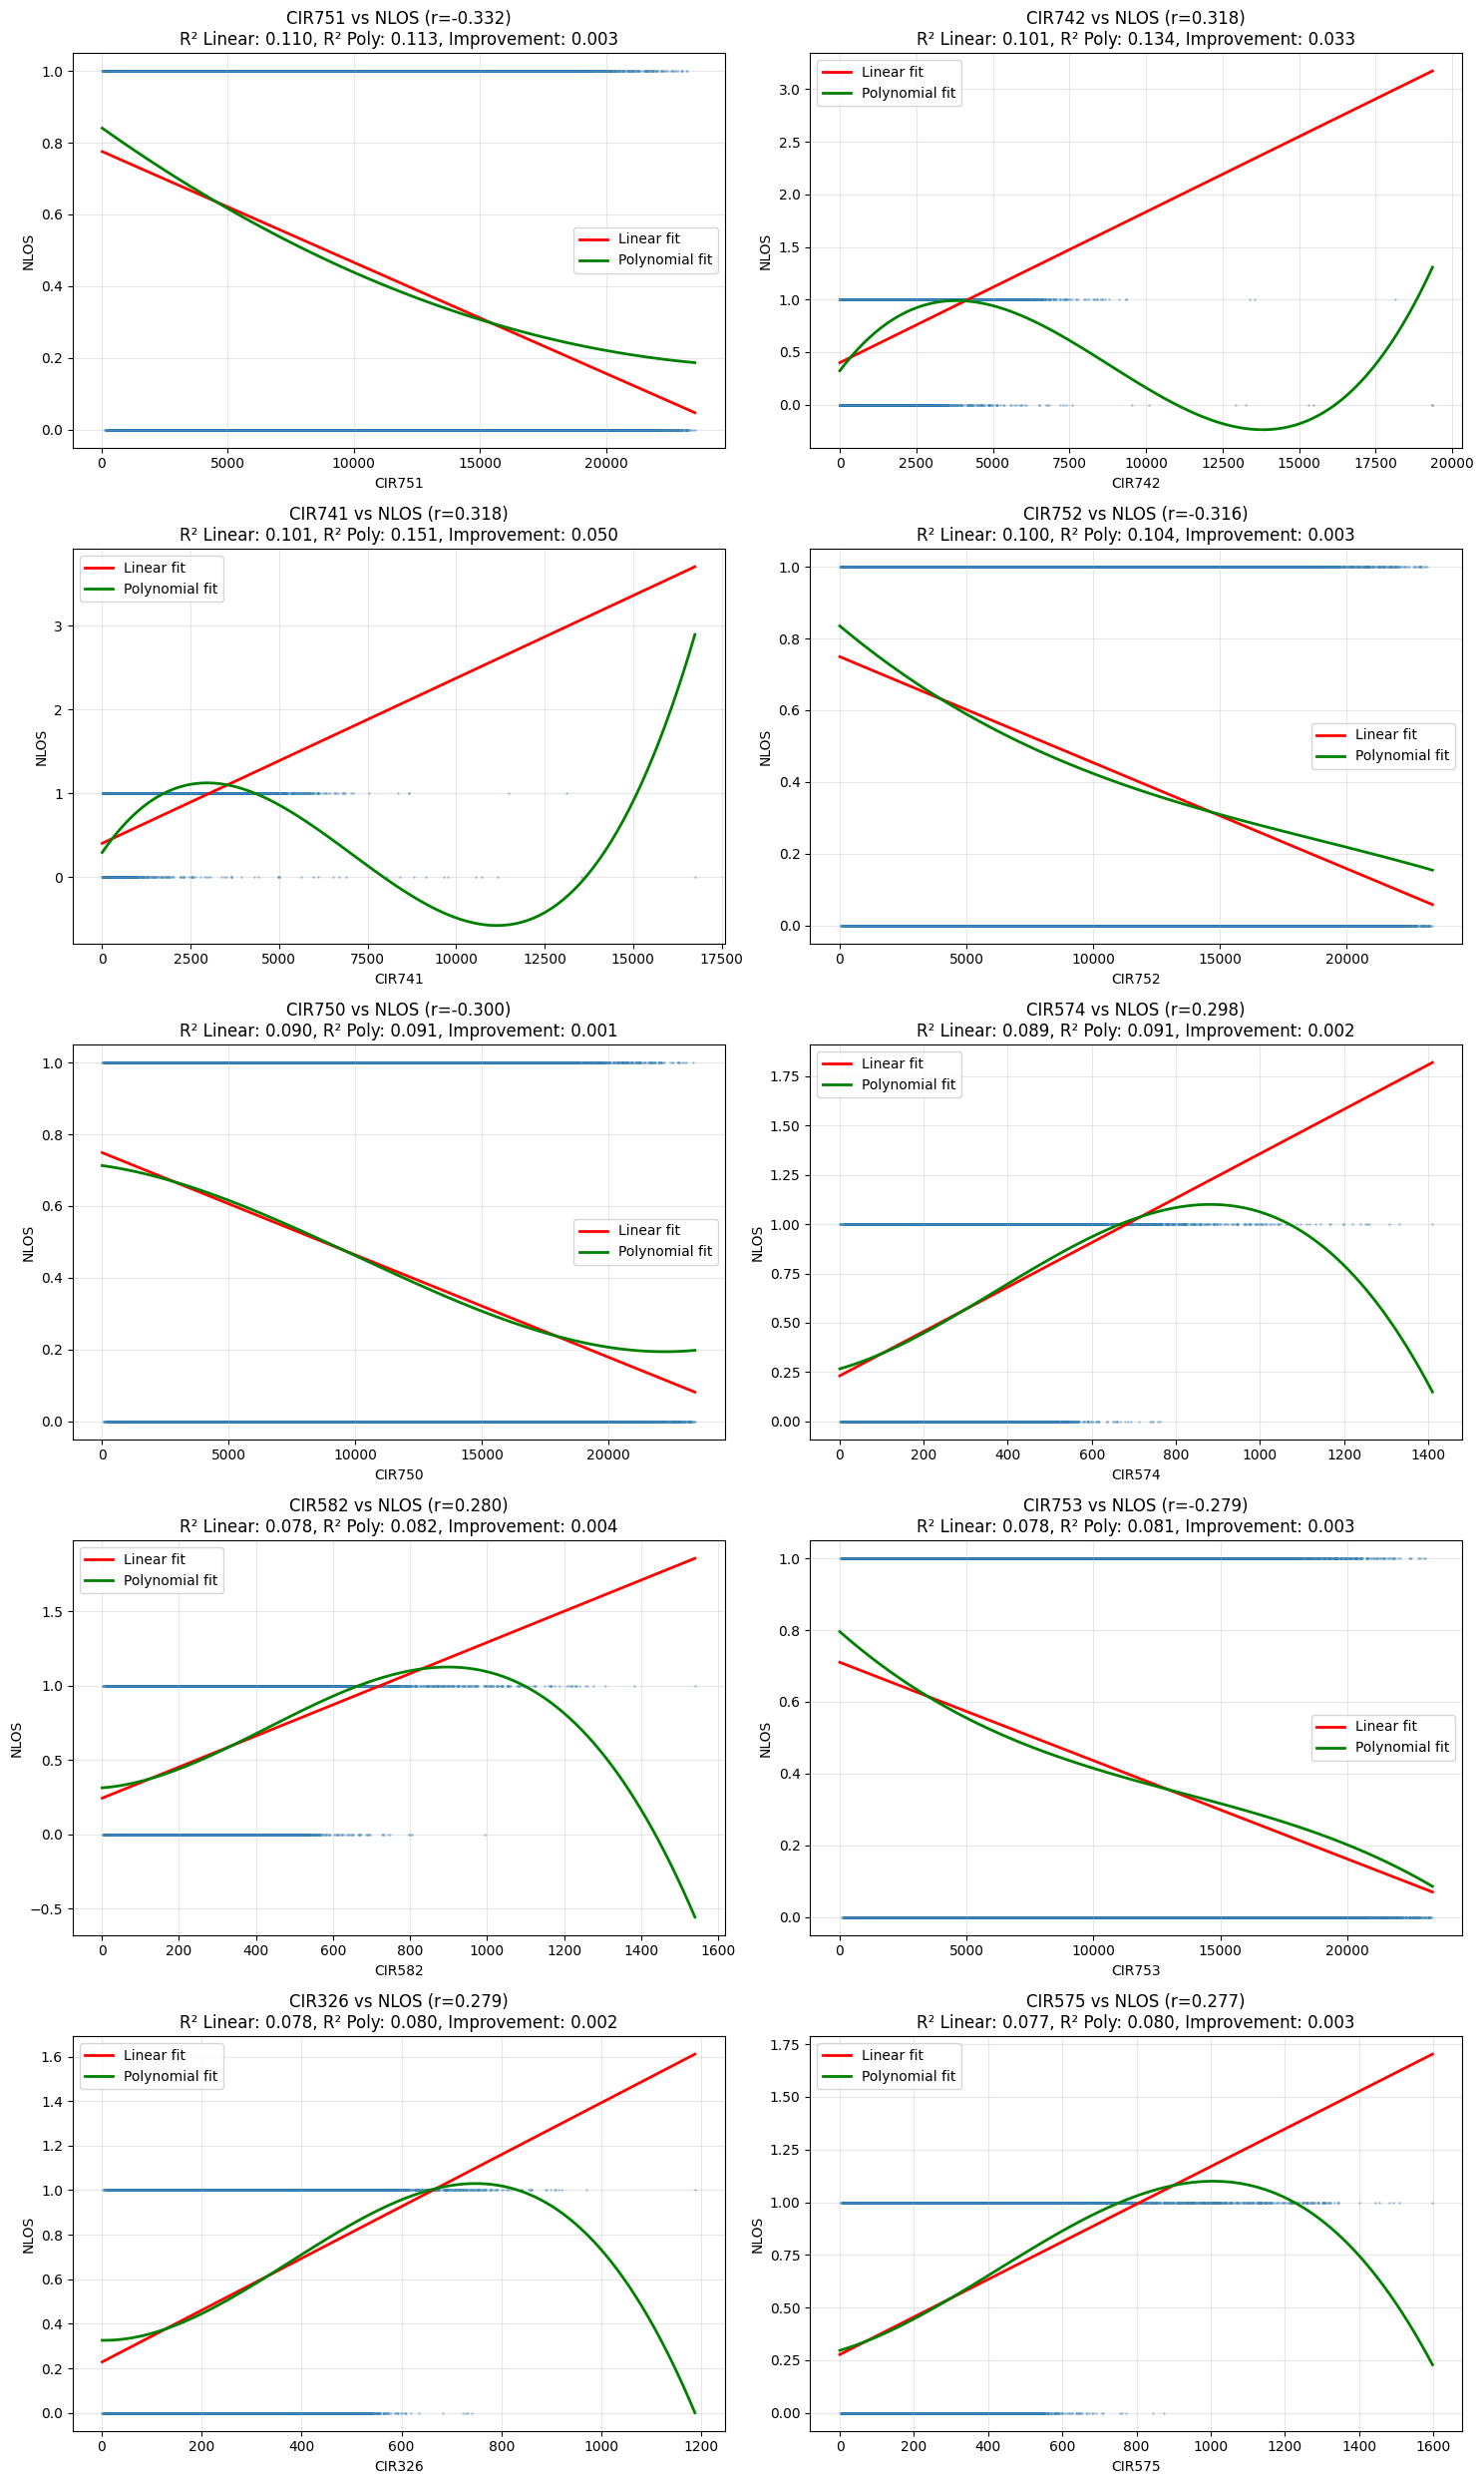

In [29]:
# Create scatter plots with linear and polynomial fits
fig, axes = plt.subplots(5, 2, figsize=(15, 25))  # 5x2 grid for 10 features
axes = axes.flatten()

for i, feature in enumerate(top_feature_names):
    ax = axes[i]
    
    # Get data
    x = pca_data[feature].values.reshape(-1, 1)
    y = target.values
    
    # Scatter plot
    ax.scatter(x, y, alpha=0.3, s=1)
    
    # Linear fit
    lr = LinearRegression()
    lr.fit(x, y)
    x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    ax.plot(x_range, lr.predict(x_range), 'r-', linewidth=2, label='Linear fit')
    
    # Polynomial fit (3rd degree) - instead of LOWESS
    poly = PolynomialFeatures(degree=3)
    x_poly = poly.fit_transform(x)
    x_range_poly = poly.transform(x_range)
    
    lr_poly = LinearRegression()
    lr_poly.fit(x_poly, y)
    y_poly = lr_poly.predict(x_range_poly)
    
    ax.plot(x_range, y_poly, 'g-', linewidth=2, label='Polynomial fit')
    
    # Compute R-squared for linear and polynomial models
    y_pred_linear = lr.predict(x)
    r2_linear = np.corrcoef(y, y_pred_linear.flatten())[0, 1]**2
    
    y_pred_poly = lr_poly.predict(x_poly)
    r2_poly = np.corrcoef(y, y_pred_poly)[0, 1]**2
    
    # Add R-squared improvement to title
    r2_improvement = r2_poly - r2_linear
    
    ax.set_title(f'{feature} vs NLOS (r={correlation_with_target[feature]:.3f})\nR² Linear: {r2_linear:.3f}, R² Poly: {r2_poly:.3f}, Improvement: {r2_improvement:.3f}')
    ax.set_xlabel(feature)
    ax.set_ylabel('NLOS')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Prepare data
X = pca_data.copy()
y = target.copy()

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and evaluate models
models = {
    'Logistic Regression (linear)': LogisticRegression(max_iter=1000),
    'Neural Network (non-linear)': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300),
    'Random Forest (non-linear)': RandomForestClassifier(n_estimators=100)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} - Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

Logistic Regression (linear) - Accuracy: 0.8226
              precision    recall  f1-score   support

         0.0       0.79      0.88      0.83      6250
         1.0       0.86      0.77      0.81      6350

    accuracy                           0.82     12600
   macro avg       0.83      0.82      0.82     12600
weighted avg       0.83      0.82      0.82     12600

Neural Network (non-linear) - Accuracy: 0.8274
              precision    recall  f1-score   support

         0.0       0.81      0.85      0.83      6250
         1.0       0.85      0.80      0.82      6350

    accuracy                           0.83     12600
   macro avg       0.83      0.83      0.83     12600
weighted avg       0.83      0.83      0.83     12600

Random Forest (non-linear) - Accuracy: 0.8244
              precision    recall  f1-score   support

         0.0       0.79      0.88      0.83      6250
         1.0       0.87      0.77      0.81      6350

    accuracy                           0.

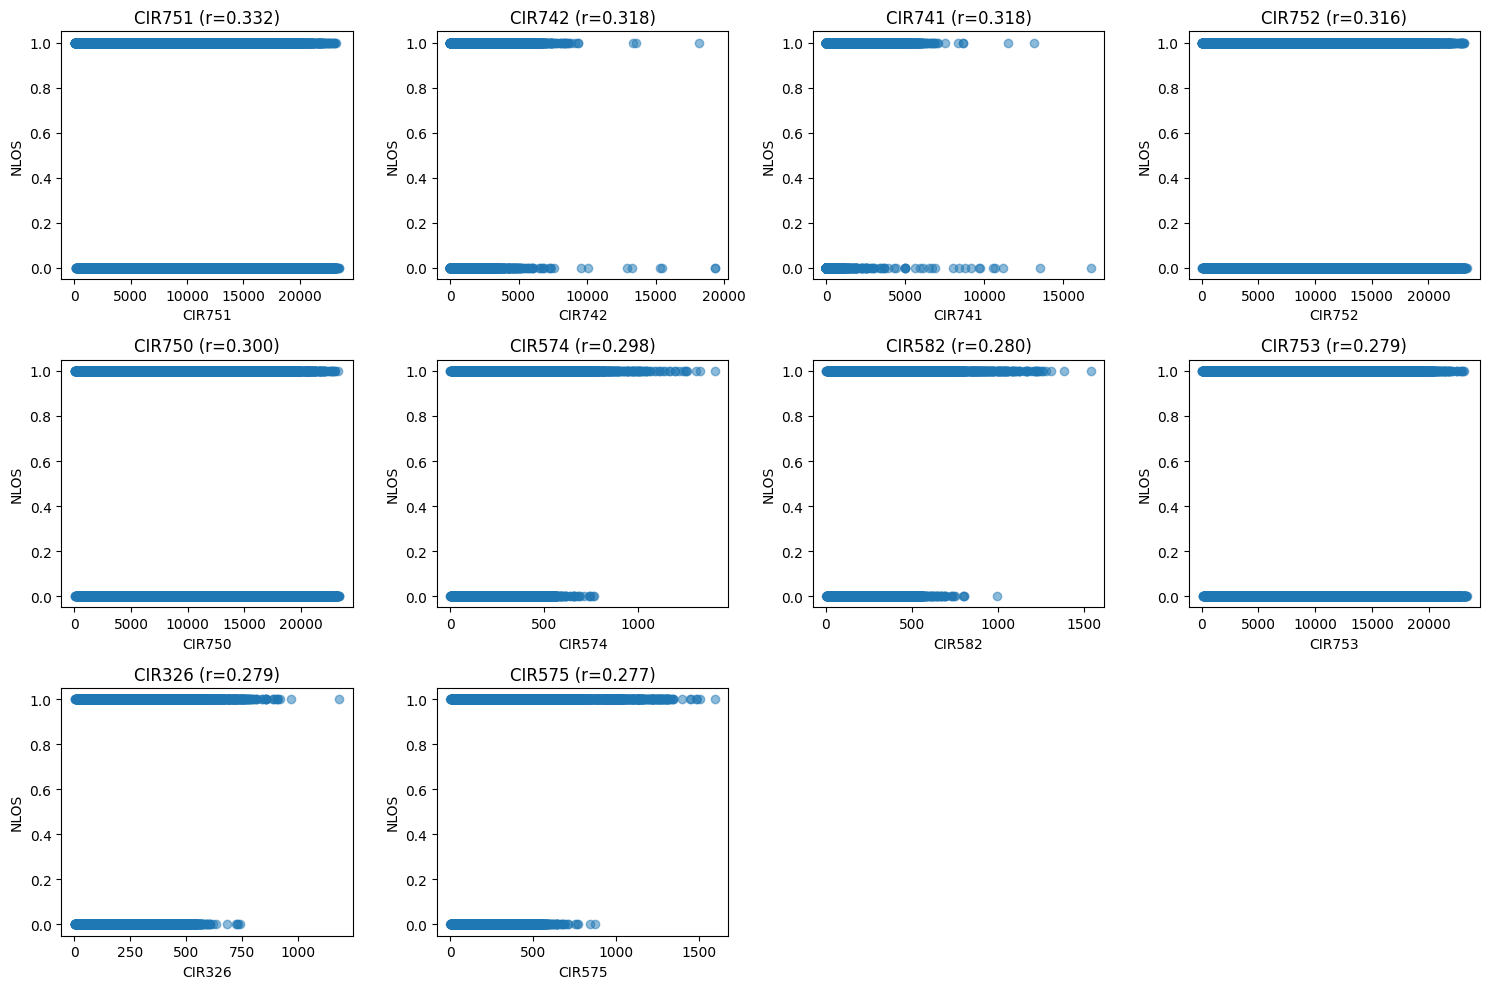

In [31]:
# Step 6: Scatter plots for top correlated features
plt.figure(figsize=(15, 10))
for i, (feature, corr) in enumerate(top_corr_features.items()):
    plt.subplot(3, 4, i+1)
    plt.scatter(pca_data[feature], target, alpha=0.5)
    plt.title(f'{feature} (r={corr:.3f})')
    plt.xlabel(feature)
    plt.ylabel('NLOS')
plt.tight_layout()
plt.savefig('top_features_scatter.png')
plt.show()

In [32]:
# Step 7: Test linear vs non-linear models on a subset of data for efficiency
# Select a smaller subset for quick model comparison
X_sample, _, y_sample, _ = train_test_split(pca_data, target, test_size=0.9, random_state=42)

In [33]:
# Standardize the features
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

# Compare a linear model vs a non-linear model
linear_model = LogisticRegression(max_iter=1000)
non_linear_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=100)


In [34]:
# Train and evaluate models
linear_model.fit(X_sample_scaled, y_sample)
non_linear_model.fit(X_sample_scaled, y_sample)

linear_pred = linear_model.predict(X_sample_scaled)
non_linear_pred = non_linear_model.predict(X_sample_scaled)

linear_acc = accuracy_score(y_sample, linear_pred)
non_linear_acc = accuracy_score(y_sample, non_linear_pred)

print(f"Linear model accuracy: {linear_acc:.4f}")
print(f"Non-linear model accuracy: {non_linear_acc:.4f}")
print(f"Difference (non-linear - linear): {non_linear_acc - linear_acc:.4f}")
print("A large positive difference suggests non-linear relationships")

Linear model accuracy: 0.9010
Non-linear model accuracy: 1.0000
Difference (non-linear - linear): 0.0990
A large positive difference suggests non-linear relationships


#### **t-SNE && UMAP for dimensionality reduction**

In [35]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Extract CIR data and labels
X = pca_data.values  # CIR0 to CIR1015
y = combined_data_with_encoding['NLOS'].values  # LOS/NLOS labels

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [36]:
# t-SNE (2D)
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

In [37]:
# Add transformed data back into your DataFrame
combined_data_with_encoding['tSNE_1'] = X_tsne[:, 0]
combined_data_with_encoding['tSNE_2'] = X_tsne[:, 1]

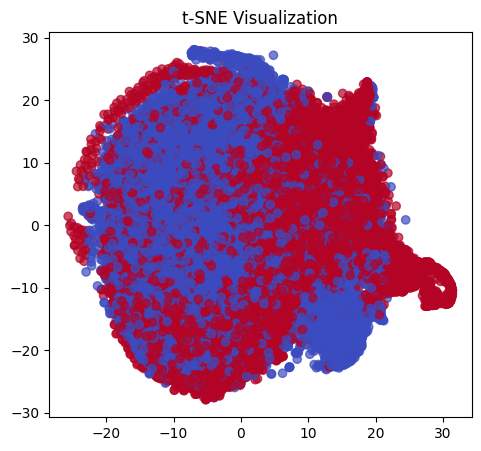

In [38]:
plt.figure(figsize=(12, 5))

# t-SNE plot
plt.subplot(1, 2, 1)
plt.scatter(combined_data_with_encoding['tSNE_1'], combined_data_with_encoding['tSNE_2'], c=y, cmap='coolwarm', alpha=0.7)
plt.title('t-SNE Visualization')

plt.show()


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Prepare t-SNE and UMAP data for modeling
X_tsne = combined_data_with_encoding[['tSNE_1', 'tSNE_2']]
y = combined_data_with_encoding['NLOS']

# Train-test split
X_train_tsne, X_test_tsne, y_train, y_test = train_test_split(X_tsne, y, test_size=0.3, random_state=42)

# Train SVM
svm_tsne = SVC()
svm_tsne.fit(X_train_tsne, y_train)

# Predictions
y_pred_tsne = svm_tsne.predict(X_test_tsne)

# Accuracy
print("t-SNE + SVM Accuracy:", accuracy_score(y_test, y_pred_tsne))


t-SNE + SVM Accuracy: 0.7585714285714286


In [40]:
combined_data_with_encoding = combined_data_with_encoding.drop(columns=['tSNE_1', 'tSNE_2'])

#### **Do manual feature extraction on CIR** 

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import skew, kurtosis

def extract_cir_features(df):
    """
    Extract statistical features from CIR time series data (CIR0 to CIR1015)
    """
    # Create feature DataFrame
    features = pd.DataFrame(index=df.index)
    
    # Extract CIR data as array for each row
    cir_data = df.values
    
    # Calculate statistical features
    features['cir_max'] = np.max(cir_data, axis=1)
    features['cir_min'] = np.min(cir_data, axis=1)
    features['cir_mean'] = np.mean(cir_data, axis=1)
    features['cir_std'] = np.std(cir_data, axis=1)
    features['cir_median'] = np.median(cir_data, axis=1)
    features['cir_energy'] = np.sum(cir_data**2, axis=1)
    features['cir_skewness'] = skew(cir_data, axis=1)
    features['cir_kurtosis'] = kurtosis(cir_data, axis=1)
    
    # Time-domain features
    features['cir_max_idx'] = np.argmax(cir_data, axis=1)  # Index of maximum value
    
    # First significant peak (values above mean + std)
    first_peaks = []
    for row in cir_data:
        threshold = np.mean(row) + np.std(row)
        peaks = np.where(row > threshold)[0]
        first_peak = peaks[0] if len(peaks) > 0 else -1
        first_peaks.append(first_peak)
    features['cir_first_peak_idx'] = first_peaks
    
    # Count of peaks above threshold
    peak_counts = []
    for row in cir_data:
        threshold = np.mean(row) + np.std(row)
        peaks = np.sum(row > threshold)
        peak_counts.append(peaks)
    features['cir_peak_count'] = peak_counts
    
    # Calculate percentiles
    features['cir_25_percentile'] = np.percentile(cir_data, 25, axis=1)
    features['cir_75_percentile'] = np.percentile(cir_data, 75, axis=1)
    features['cir_iqr'] = features['cir_75_percentile'] - features['cir_25_percentile']
    
    # Power-related features
    features['cir_power'] = np.sum(np.abs(cir_data), axis=1)
    features['cir_rms'] = np.sqrt(np.mean(cir_data**2, axis=1))
    
    # First and last non-zero values
    first_non_zero = []
    last_non_zero = []
    for row in cir_data:
        non_zeros = np.where(np.abs(row) > 0.01)[0]  # Adjust threshold as needed
        first = non_zeros[0] if len(non_zeros) > 0 else -1
        last = non_zeros[-1] if len(non_zeros) > 0 else -1
        first_non_zero.append(first)
        last_non_zero.append(last)
    
    features['cir_first_non_zero'] = first_non_zero
    features['cir_last_non_zero'] = last_non_zero
    features['cir_signal_length'] = features['cir_last_non_zero'] - features['cir_first_non_zero']
    
    # Add ratio features
    features['cir_max_mean_ratio'] = features['cir_max'] / (features['cir_mean'] + 1e-10)
    
    return features

In [42]:
print("Extracting features from pca_data...")
cir_features = extract_cir_features(pca_data)

# Display the first few rows of extracted features
print("\nExtracted CIR features:")
cir_features.head()

Extracting features from pca_data...

Extracted CIR features:


,cir_max,cir_min,cir_mean,cir_std,cir_median,cir_energy,cir_skewness,cir_kurtosis,cir_max_idx,cir_first_peak_idx,cir_peak_count,cir_25_percentile,cir_75_percentile,cir_iqr,cir_power,cir_rms,cir_first_non_zero,cir_last_non_zero,cir_signal_length,cir_max_mean_ratio
0,23077.0,0.0,395.225394,1225.669636,221.0,1.685005e+09,10.545582,144.958572,748,744,25,158.75,286.25,127.50,401549.0,1287.815658,0,1014,1014,58.389467
1,18059.0,0.0,444.060039,1631.688252,210.5,2.905349e+09,8.510976,77.034432,757,750,25,136.00,272.00,136.00,451165.0,1691.033965,0,1014,1014,40.667924
2,16809.0,0.0,503.485236,1362.842157,231.5,2.144610e+09,7.090688,58.383480,754,747,44,159.00,310.25,151.25,511541.0,1452.871683,0,1014,1014,33.385289
3,15742.0,13.0,413.054134,1046.969988,256.0,1.287028e+09,9.471998,105.653200,756,750,26,183.00,365.00,182.00,419663.0,1125.504275,0,1015,1015,38.111227
4,19583.0,1.0,363.357283,1198.971453,228.0,1.594674e+09,11.772332,151.456101,750,745,16,151.75,291.00,139.25,369171.0,1252.821240,0,1015,1015,53.894613


In [43]:
# Select only the extracted CIR features for modeling
X = cir_features
y = combined_data_with_encoding['NLOS']  # Adjust if your target has a different name

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")


Training set size: (29400, 20)
Test set size: (12600, 20)


In [45]:
svm_classifier = SVC()
svm_classifier.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_classifier.predict(X_test)

# Calculate accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM with extracted CIR features accuracy: {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")

# Display classification report
print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm))


SVM with extracted CIR features accuracy: 0.6980 (69.80%)

Classification Report (SVM):
              precision    recall  f1-score   support

         0.0       0.64      0.92      0.75      6300
         1.0       0.86      0.48      0.61      6300

    accuracy                           0.70     12600
   macro avg       0.75      0.70      0.68     12600
weighted avg       0.75      0.70      0.68     12600



In [46]:
print("\nTraining Random Forest with extracted CIR features...")
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_classifier.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest with extracted CIR features accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

# Display classification report
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))


Training Random Forest with extracted CIR features...
Random Forest with extracted CIR features accuracy: 0.8277 (82.77%)

Classification Report (Random Forest):
              precision    recall  f1-score   support

         0.0       0.78      0.90      0.84      6300
         1.0       0.89      0.75      0.81      6300

    accuracy                           0.83     12600
   macro avg       0.84      0.83      0.83     12600
weighted avg       0.84      0.83      0.83     12600



In [47]:
print(f"Extracted CIR Features + SVM Accuracy: {svm_accuracy*100:.2f}%")
print(f"Extracted CIR Features + Random Forest Accuracy: {rf_accuracy*100:.2f}%")
print(f"Improvement (best model vs. t-SNE): {max(svm_accuracy, rf_accuracy)*100 - 75:.2f}%")

Extracted CIR Features + SVM Accuracy: 69.80%
Extracted CIR Features + Random Forest Accuracy: 82.77%
Improvement (best model vs. t-SNE): 7.77%


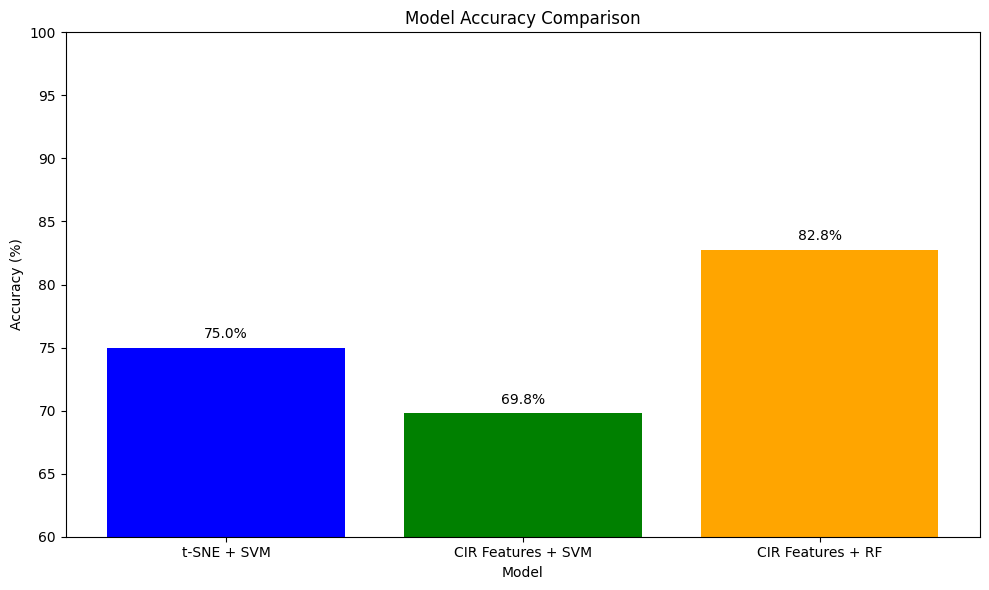

In [48]:
# Plot comparison bar chart
plt.figure(figsize=(10, 6))
models = ['t-SNE + SVM', 'CIR Features + SVM', 'CIR Features + RF']
accuracies = [75, svm_accuracy*100, rf_accuracy*100]
colors = ['blue', 'green', 'orange']

bars = plt.bar(models, accuracies, color=colors)
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(60, 100)  # Adjust as needed

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

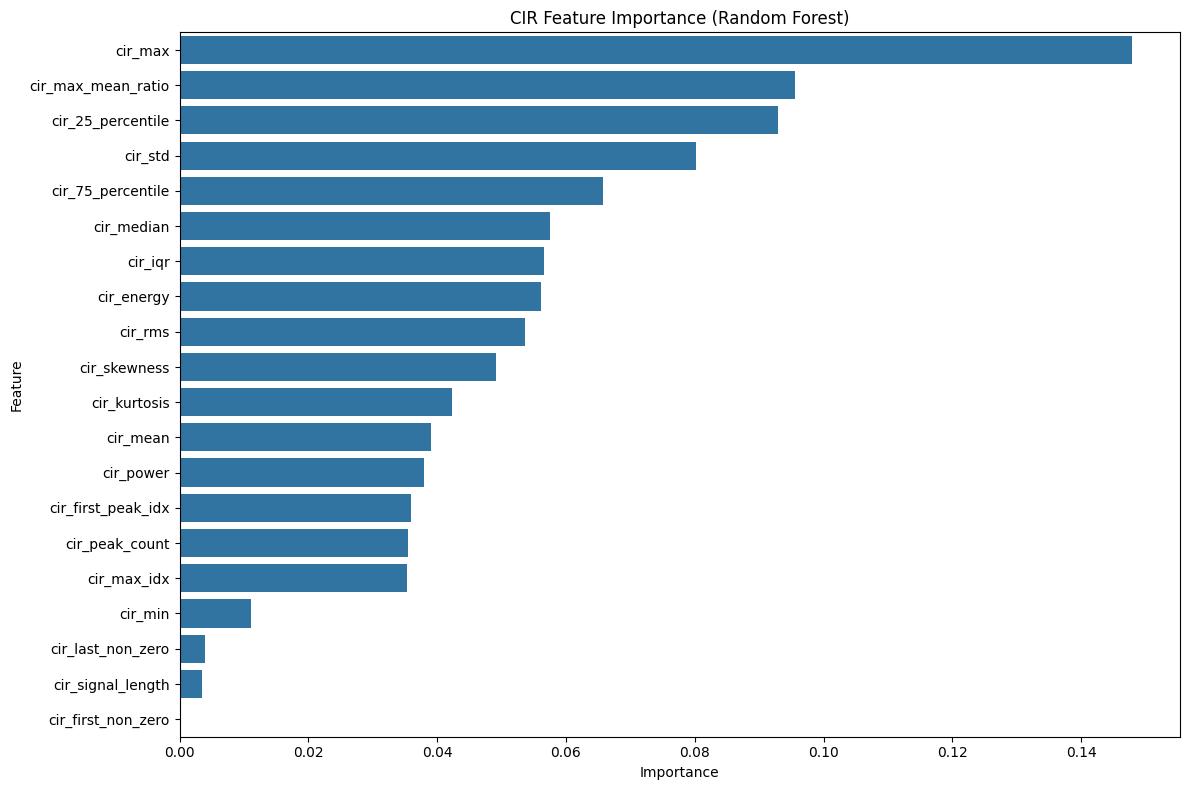

In [49]:
# Get feature importance from the Random Forest model
feature_importance = pd.DataFrame({
    'Feature': cir_features.columns,
    'Importance': rf_classifier.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('CIR Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

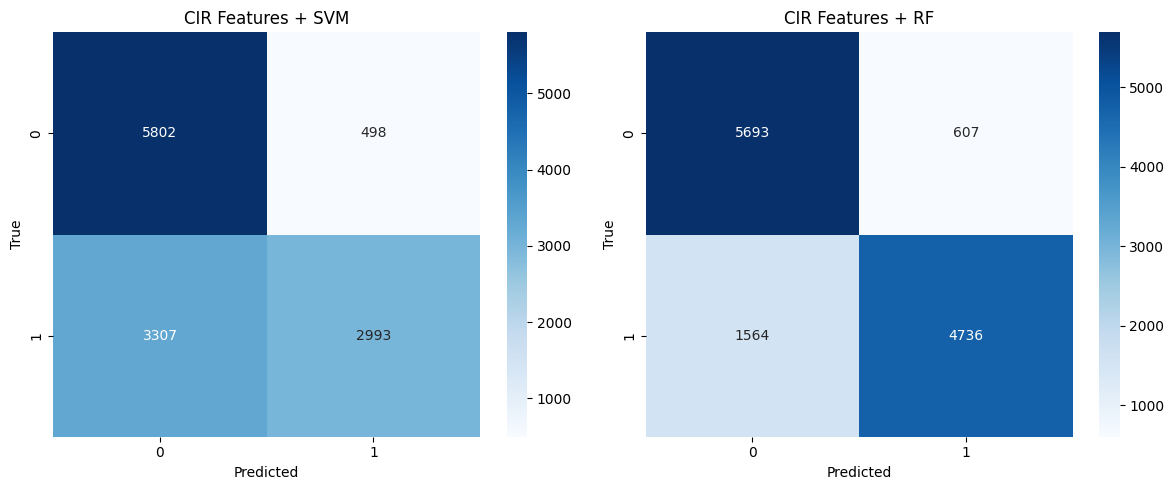

In [50]:
plt.figure(figsize=(12, 5))

# Features + SVM
plt.subplot(1, 2, 1)
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CIR Features + SVM')

# Features + RF
plt.subplot(1, 2, 2)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CIR Features + RF')

plt.tight_layout()
plt.show()

#### **Combined with the other features** 

In [51]:
# Select all columns that are not in the CIR0 to CIR1015 range
other_features = combined_data_with_encoding.drop(columns=pca_data.columns).copy()

In [52]:
combined_data_with_X_tsne = pd.concat([X_tsne, other_features], axis=1)

In [53]:
print(combined_data_with_X_tsne)

          tSNE_1     tSNE_2  NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  \
0       1.612000  10.075953   0.0   3.90   745.0  18712.0  10250.0  11576.0   
1     -16.749971   2.422682   0.0   0.66   749.0  11239.0   6313.0   4712.0   
2      -8.088640 -17.815004   1.0   7.86   746.0   4355.0   5240.0   3478.0   
3      11.985237   5.361519   1.0   3.48   750.0   8502.0   8416.0   5890.0   
4      -3.940747  10.947730   0.0   1.19   746.0  17845.0  18095.0  12058.0   
...          ...        ...   ...    ...     ...      ...      ...      ...   
41995   2.528090   0.610538   0.0   2.43   745.0  12960.0  17703.0  14948.0   
41996  -2.766215   2.991300   0.0   1.39   745.0   2235.0  15089.0   8796.0   
41997   6.805053  -0.152897   1.0   5.48   747.0   7115.0   6262.0   4584.0   
41998  12.208063   9.172737   1.0   3.40   745.0   6662.0   7683.0   5600.0   
41999  -9.572930   7.891329   0.0   2.43   747.0   2621.0  10276.0   6284.0   

       STDEV_NOISE  CIR_PWR  ...  PRFR  Environment

In [54]:
print(combined_data_with_X_tsne.columns.tolist())

['tSNE_1', 'tSNE_2', 'NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'CH', 'FRAME_LEN', 'PREAM_LEN', 'BITRATE', 'PRFR', 'Environment', 'Env_Bedroom', 'Env_Boiler room', 'Env_Kitchen with a living room', 'Env_Office 1', 'Env_Office 2', 'Env_Small Apartment', 'Env_Small Workshop', 'FP_POWER']


#### **Feature Importance Ranking** 

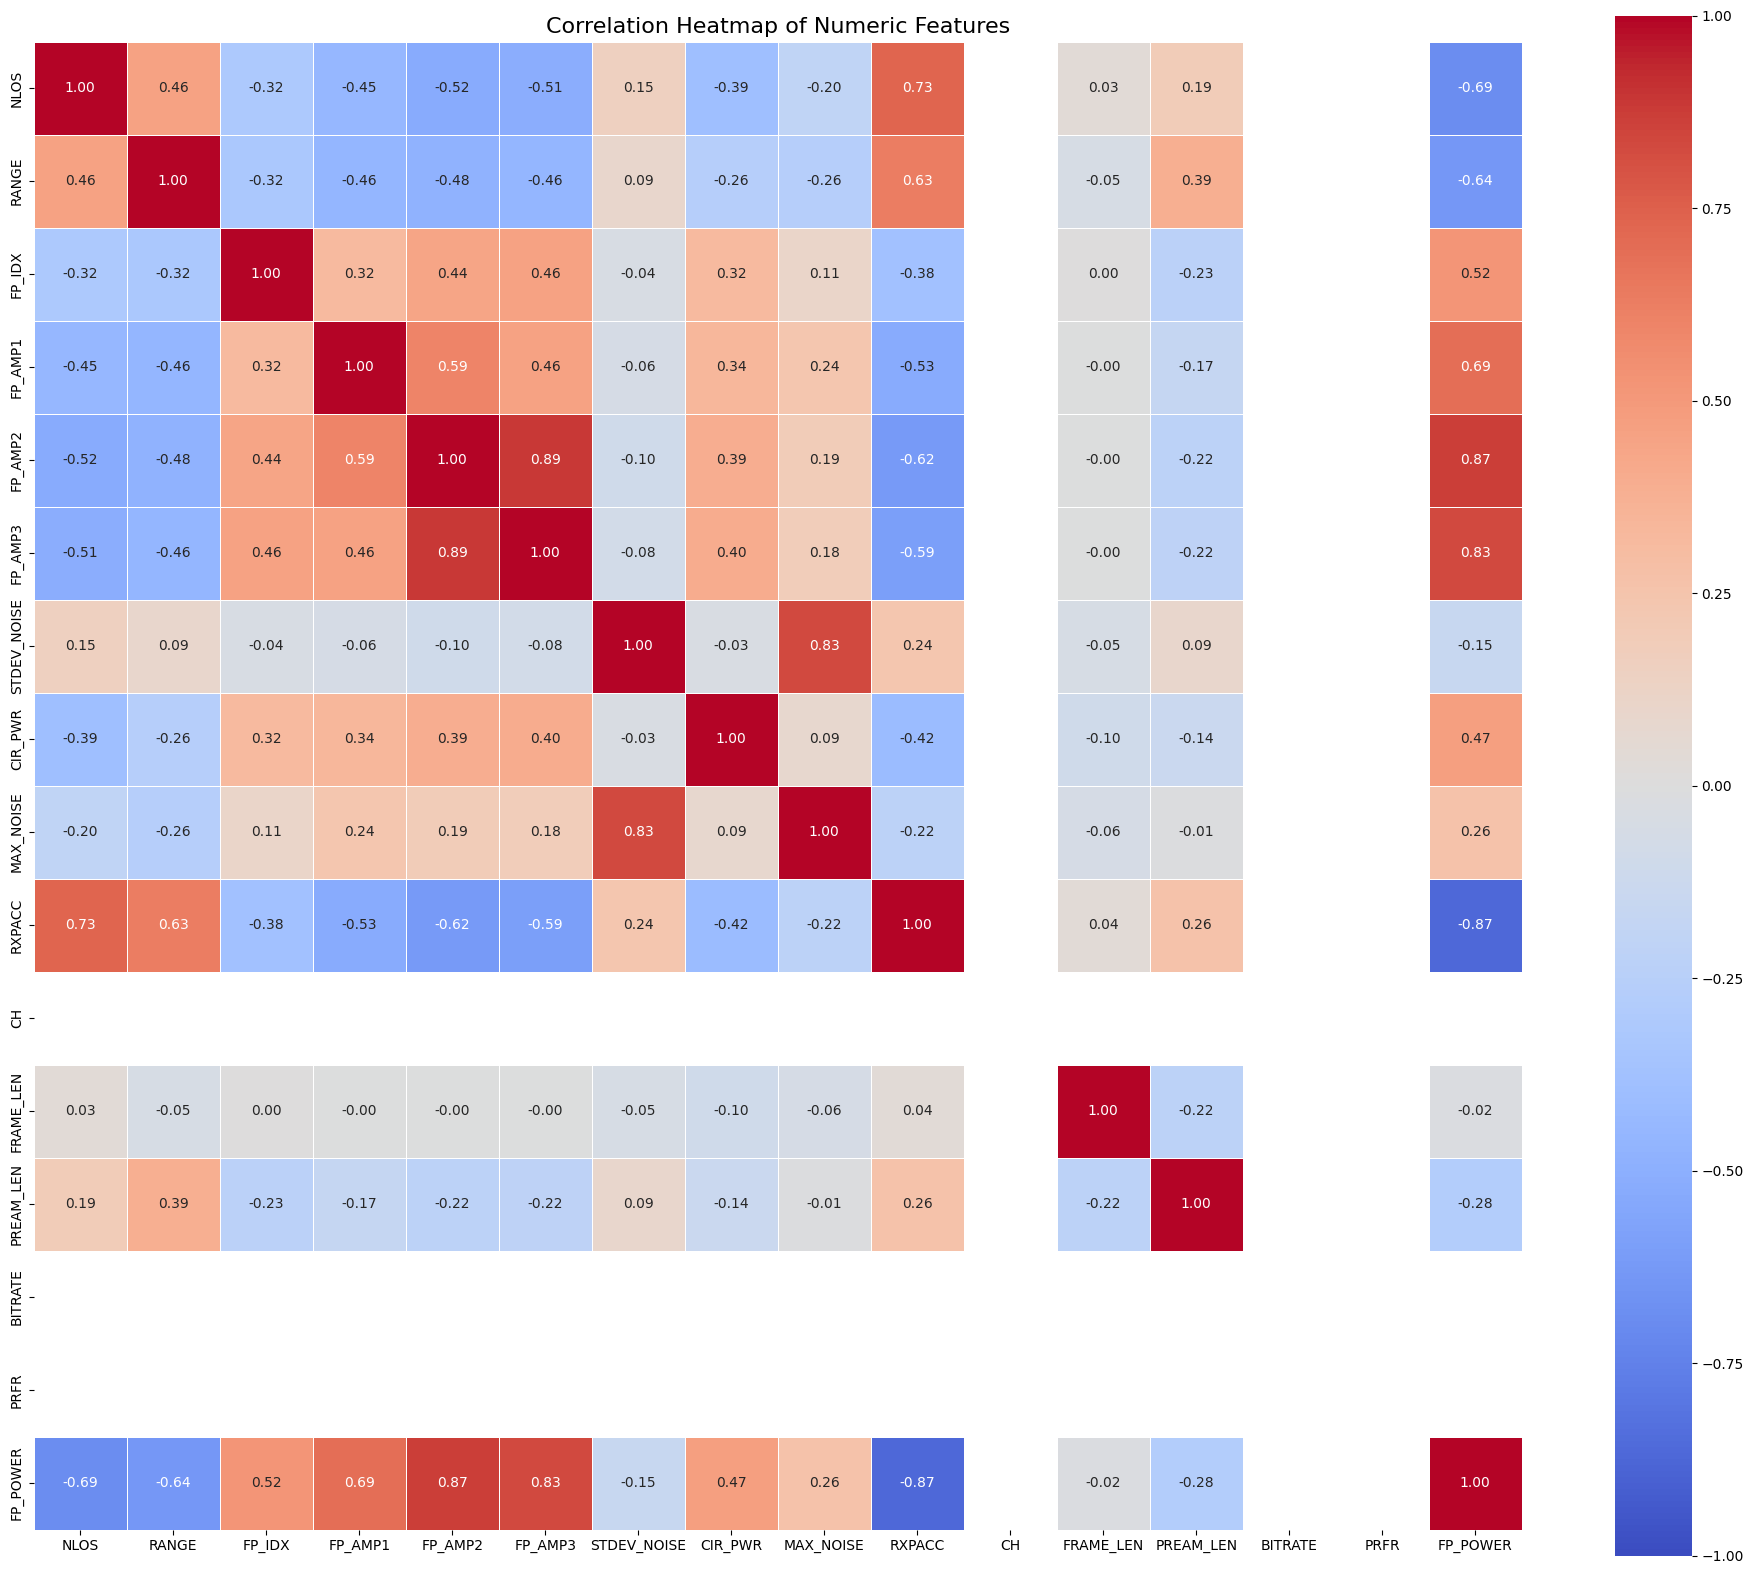

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt


# Exclude non-numeric columns (e.g., 'Environment')
numeric_features = combined_data_with_X_tsne.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
corr_matrix = numeric_features.corr()

# Set up the matplotlib figure
plt.figure(figsize=(24, 20))

# Create the heatmap
sns.heatmap(
    corr_matrix,  # Correlation matrix
    annot=True,   # Annotate the heatmap with the correlation values
    fmt=".2f",    # Format the annotations to 2 decimal places
    cmap="coolwarm",  # Color map
    vmin=-1,      # Minimum value for the color scale
    vmax=1,       # Maximum value for the color scale
    linewidths=0.5,  # Add lines between cells
    square=True   # Ensure the heatmap is square
)

# Add a title
plt.title("Correlation Heatmap of Numeric Features", fontsize=16)

# Show the plot
plt.show()

In [56]:
#Feature Importance Ranking

# Drop the 'Environment' column (and any other non-numeric columns if present)
combined_data_with_pca_FIR = combined_data_with_X_tsne.drop(columns=['Environment'])

# Separate features (X) and target (y)
X = combined_data_with_pca_FIR.drop(columns=['NLOS'])
y = combined_data_with_pca_FIR['NLOS']

In [57]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X, y)

# Get feature importances
importances = rf_classifier.feature_importances_

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the all features
print(feature_importance_df)

                           Feature  Importance
10                          RXPACC    0.233198
23                        FP_POWER    0.161793
2                            RANGE    0.110589
8                          CIR_PWR    0.098127
6                          FP_AMP3    0.071207
5                          FP_AMP2    0.060709
9                        MAX_NOISE    0.058267
0                           tSNE_1    0.057224
4                          FP_AMP1    0.037017
1                           tSNE_2    0.035445
7                      STDEV_NOISE    0.031519
3                           FP_IDX    0.020862
12                       FRAME_LEN    0.004291
20                    Env_Office 2    0.002767
16                     Env_Bedroom    0.002610
18  Env_Kitchen with a living room    0.002584
21             Env_Small Apartment    0.002573
22              Env_Small Workshop    0.002551
19                    Env_Office 1    0.002541
17                 Env_Boiler room    0.002316
13           

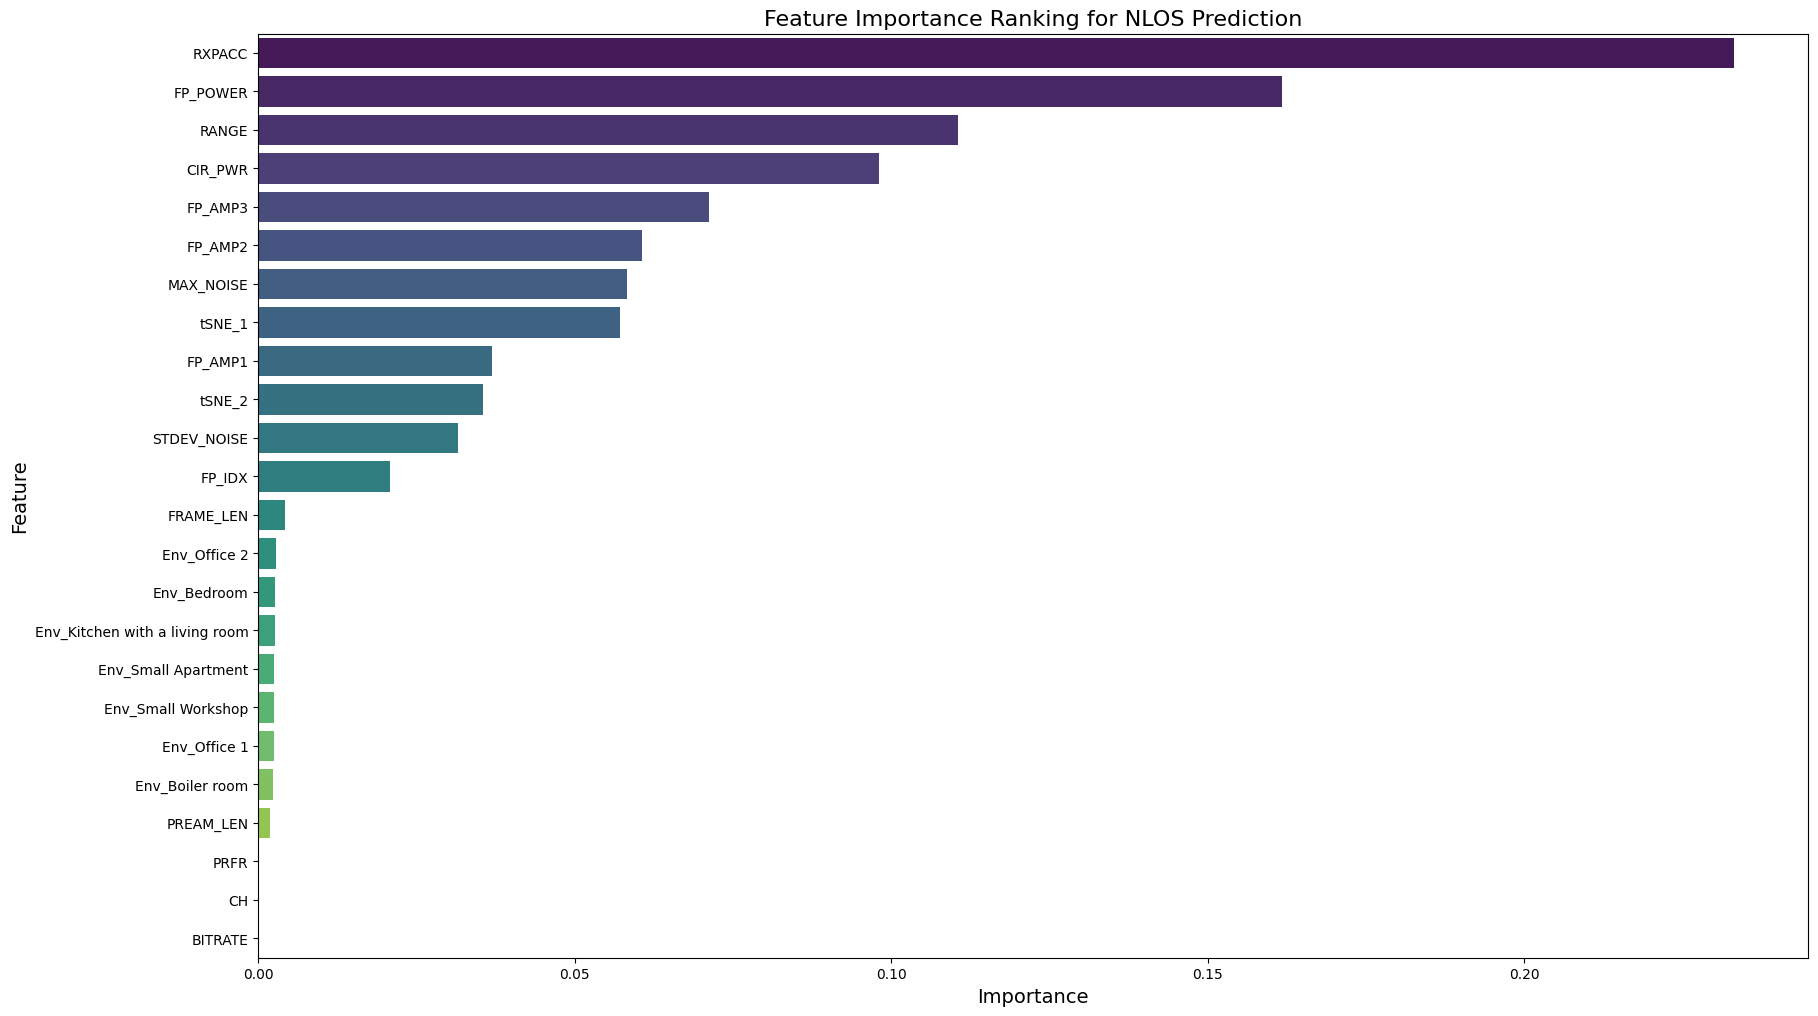

In [58]:
# Plot the top 10 most important features
plt.figure(figsize=(20, 12))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    hue='Feature',  # Assign the y variable to hue
    palette='viridis', 
    legend=False  # Disable the legend
)
plt.title('Feature Importance Ranking for NLOS Prediction', fontsize=16)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.show()

#### **Data Cleaning [Part 2]** 

In [59]:
# find columns with only 1 unique value
unique_counts = combined_data_with_X_tsne.nunique()
single_value_cols = unique_counts[unique_counts == 1]
print("Columns with only one unique value:")
if not single_value_cols.empty:
    print(single_value_cols)
else:
    print("No columns with a single unique value.")

Columns with only one unique value:
CH         1
BITRATE    1
PRFR       1
dtype: int64


In [60]:
# Select only numeric columns
numeric_data = combined_data_with_X_tsne.select_dtypes(include=['number'])

# Check for features with low variance (below a given threshold)
variance_threshold = 0.01  # Adjust the threshold as needed
low_variance_columns = numeric_data.columns[numeric_data.var() < variance_threshold]

print("Features with low variance (numeric only):")
print(low_variance_columns)


Features with low variance (numeric only):
Index(['CH', 'BITRATE', 'PRFR'], dtype='object')


In [61]:
import numpy as np
import pandas as pd

# Assuming combined_data_with_X_tsne is the dataframe you're working with
X = combined_data_with_X_tsne.drop(columns=['NLOS'])  # Exclude target variable for checking

# Check for NaN values in each feature
nan_columns = X.columns[X.isna().any()].tolist()  # List of columns with NaN values
print("Columns with NaN values:")
print(nan_columns)

# Check for Infinite values in each feature
inf_columns = X.columns[(X == np.inf).any()].tolist()  # Columns with positive infinity
neg_inf_columns = X.columns[(X == -np.inf).any()].tolist()  # Columns with negative infinity
print("\nColumns with positive infinity values:")
print(inf_columns)

print("\nColumns with negative infinity values:")
print(neg_inf_columns)

# Combine columns with NaN, positive inf, and negative inf values
all_problem_columns = set(nan_columns + inf_columns + neg_inf_columns)
print("\nAll columns with NaN or infinite values:")
print(all_problem_columns)


Columns with NaN values:
[]

Columns with positive infinity values:
[]

Columns with negative infinity values:
[]

All columns with NaN or infinite values:
set()


In [62]:
# List of columns to drop
columns_to_drop = ['CH', 'BITRATE', 'PRFR']

# Drop the columns
combined_data_with_X_tsne = combined_data_with_X_tsne.drop(columns=columns_to_drop)

# Verify if the columns were dropped
print(f"Remaining columns after dropping: {combined_data_with_X_tsne.columns.tolist()}")

Remaining columns after dropping: ['tSNE_1', 'tSNE_2', 'NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'FRAME_LEN', 'PREAM_LEN', 'Environment', 'Env_Bedroom', 'Env_Boiler room', 'Env_Kitchen with a living room', 'Env_Office 1', 'Env_Office 2', 'Env_Small Apartment', 'Env_Small Workshop', 'FP_POWER']


#### **Dropping insignificant featuer (according to feature importance ranking)** 

In [63]:
# List of columns to drop
columns_to_drop = ['FRAME_LEN', 'PREAM_LEN']

# Drop the columns
combined_data_with_X_tsne = combined_data_with_X_tsne.drop(columns=columns_to_drop)

# Verify if the columns were dropped
print(f"Remaining columns after dropping: {combined_data_with_X_tsne.columns.tolist()}")

Remaining columns after dropping: ['tSNE_1', 'tSNE_2', 'NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'Environment', 'Env_Bedroom', 'Env_Boiler room', 'Env_Kitchen with a living room', 'Env_Office 1', 'Env_Office 2', 'Env_Small Apartment', 'Env_Small Workshop', 'FP_POWER']


#### **Outliers** 

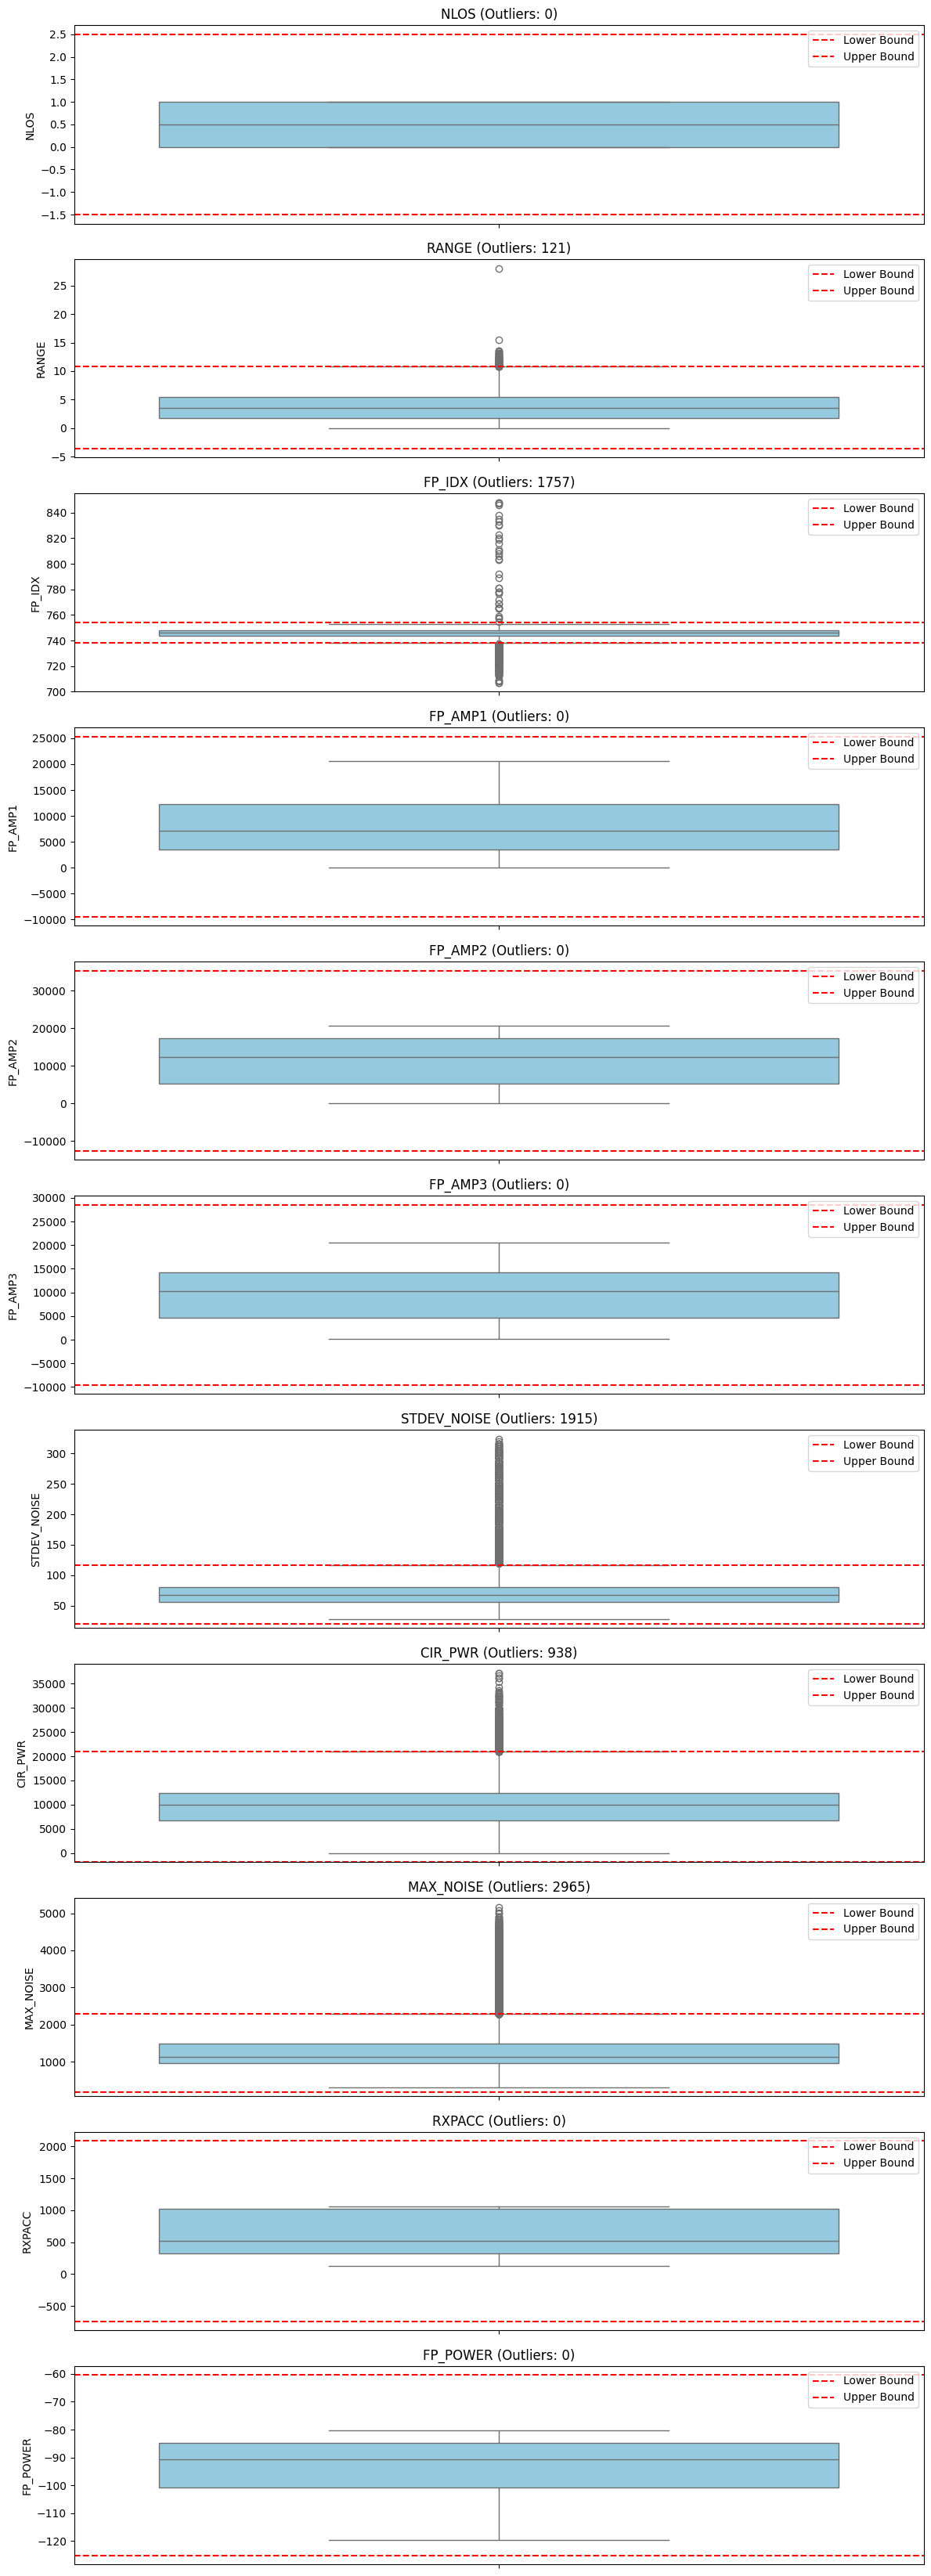

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_columns = combined_data_with_X_tsne.select_dtypes(include=['float64', 'int64']).columns

# Create a DataFrame to store outliers
outlier_counts = pd.DataFrame(columns=['Feature', 'Outlier Count'])

# Set up the figure size
plt.figure(figsize=(12, len(numeric_columns) * 3))

for i, col in enumerate(numeric_columns):
    # Calculate Q1, Q3, and IQR
    Q1 = combined_data_with_X_tsne[col].quantile(0.25)
    Q3 = combined_data_with_X_tsne[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = combined_data_with_X_tsne[(combined_data_with_X_tsne[col] < lower_bound) | (combined_data_with_X_tsne[col] > upper_bound)]
    outlier_counts.loc[i] = [col, len(outliers)]
    
    # Vertical boxplots
    plt.subplot(len(numeric_columns), 1, i + 1)
    sns.boxplot(y=combined_data_with_X_tsne[col], color='skyblue')
    plt.title(f'{col} (Outliers: {len(outliers)})')
    plt.axhline(lower_bound, color='red', linestyle='--', label='Lower Bound')
    plt.axhline(upper_bound, color='red', linestyle='--', label='Upper Bound')
    plt.legend()

plt.tight_layout()
plt.show()




In [65]:
# Display the outlier counts
print("Outlier counts for each numeric feature:")
print(outlier_counts)

Outlier counts for each numeric feature:
        Feature  Outlier Count
0          NLOS              0
1         RANGE            121
2        FP_IDX           1757
3       FP_AMP1              0
4       FP_AMP2              0
5       FP_AMP3              0
6   STDEV_NOISE           1915
7       CIR_PWR            938
8     MAX_NOISE           2965
9        RXPACC              0
10     FP_POWER              0


#### **Dropping outliers in the top 5 features only** 

In [66]:
# Top 5 most important features
top_features = ['RXPACC', 'FP_POWER', 'RANGE', 'FP_AMP3', 'CIR_PWR']

# Calculate Q1, Q3, and IQR for top features
Q1 = combined_data_with_X_tsne[top_features].quantile(0.25)
Q3 = combined_data_with_X_tsne[top_features].quantile(0.75)
IQR = Q3 - Q1

# Calculate bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify rows with outliers in top features
outlier_mask_top = (combined_data_with_X_tsne[top_features] < lower_bound) | (combined_data_with_X_tsne[top_features] > upper_bound)
rows_with_top_outliers = outlier_mask_top.any(axis=1)

# Display the number of rows with outliers in top features
print(f"Number of rows with outliers in top features: {rows_with_top_outliers.sum()}")

Number of rows with outliers in top features: 1059


In [67]:
# Drop rows with outliers in top features
cleaned_data_top = combined_data_with_X_tsne[~rows_with_top_outliers]

# Display the shape of the cleaned dataset
print(f"Shape of cleaned data (top features): {cleaned_data_top.shape}")

Shape of cleaned data (top features): (40941, 21)


#### **Dropping all outliers only** 

In [68]:
import pandas as pd

# Select only numeric columns
numeric_columns = combined_data_with_X_tsne.select_dtypes(include=['float64', 'int64']).columns

# Calculate Q1, Q3, and IQR for all numeric columns
Q1 = combined_data_with_X_tsne[numeric_columns].quantile(0.25)
Q3 = combined_data_with_X_tsne[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

# Calculate bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify rows with outliers in any feature
outlier_mask_all = (combined_data_with_X_tsne[numeric_columns] < lower_bound) | (combined_data_with_X_tsne[numeric_columns] > upper_bound)
rows_with_all_outliers = outlier_mask_all.any(axis=1)

# Display the number of rows with outliers
print(f"Number of rows with outliers in any feature: {rows_with_all_outliers.sum()}")

# Drop rows with outliers in any feature
cleaned_data_all = combined_data_with_X_tsne[~rows_with_all_outliers]

# Display the shape of the cleaned dataset
print(f"Shape of cleaned data (all features): {cleaned_data_all.shape}")

Number of rows with outliers in any feature: 6066
Shape of cleaned data (all features): (35934, 21)


#### **Comparing Accuracy only** 

In [69]:
print(combined_data_with_X_tsne.columns.tolist())

['tSNE_1', 'tSNE_2', 'NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'Environment', 'Env_Bedroom', 'Env_Boiler room', 'Env_Kitchen with a living room', 'Env_Office 1', 'Env_Office 2', 'Env_Small Apartment', 'Env_Small Workshop', 'FP_POWER']


In [70]:
print(combined_data_with_X_tsne.dtypes)

tSNE_1                            float32
tSNE_2                            float32
NLOS                              float64
RANGE                             float64
FP_IDX                            float64
FP_AMP1                           float64
FP_AMP2                           float64
FP_AMP3                           float64
STDEV_NOISE                       float64
CIR_PWR                           float64
MAX_NOISE                         float64
RXPACC                            float64
Environment                        object
Env_Bedroom                          bool
Env_Boiler room                      bool
Env_Kitchen with a living room       bool
Env_Office 1                         bool
Env_Office 2                         bool
Env_Small Apartment                  bool
Env_Small Workshop                   bool
FP_POWER                          float64
dtype: object


In [71]:
print(cleaned_data_all.select_dtypes(include=['float32', 'float64', 'int64']).columns.tolist())

['tSNE_1', 'tSNE_2', 'NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'FP_POWER']


In [72]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Filter columns with specific data types (float32, float64, int64) and exclude 'NLOS'
numeric_columns = cleaned_data_all.select_dtypes(include=['float32', 'float64', 'int64']).columns
numeric_columns = numeric_columns.drop('NLOS')  # Explicitly drop 'NLOS' from features

# Split the data into training and testing sets
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    cleaned_data_all[numeric_columns],  # Features (numeric columns, excluding 'NLOS')
    cleaned_data_all['NLOS'],          # Target
    test_size=0.3,
    random_state=42
)

# Train a Random Forest model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_all, y_train_all)

# Evaluate accuracy
y_pred_all = rf_classifier.predict(X_test_all)
accuracy_all = accuracy_score(y_test_all, y_pred_all)
print(f"Accuracy (numeric features only, 'NLOS' dropped): {accuracy_all:.4f}")

Accuracy (numeric features only, 'NLOS' dropped): 0.9059


In [73]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Filter columns with specific data types (float32, float64, int64) and exclude 'NLOS'
numeric_columns_top = cleaned_data_top.select_dtypes(include=['float32', 'float64', 'int64']).columns
numeric_columns_top = numeric_columns_top.drop('NLOS')  # Explicitly drop 'NLOS' from features

# Split the cleaned data (top features only) into training and testing sets
X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    cleaned_data_top[numeric_columns_top],  # Features (numeric columns, excluding 'NLOS')
    cleaned_data_top['NLOS'],               # Target
    test_size=0.3,
    random_state=42
)

# Train a Random Forest model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_top, y_train_top)

# Evaluate accuracy
y_pred_top = rf_classifier.predict(X_test_top)
accuracy_top = accuracy_score(y_test_top, y_pred_top)
print(f"Accuracy (top features cleaned, 'NLOS' dropped): {accuracy_top:.4f}")

Accuracy (top features cleaned, 'NLOS' dropped): 0.9174


#### **Classifier Model for NLOS and LOS** 

In [74]:
#Find out the variance of the entire dataset 

import pandas as pd

# Calculate overall variance for each feature
feature_variances = cleaned_data_top.var(numeric_only=True)
feature_variances = feature_variances.sort_values(ascending=False)
pd.set_option('display.float_format', '{:.2f}'.format)
print("Overall Variance of Features (sorted):\n")
print(feature_variances)

# Calculate variance per environment
env_variances = cleaned_data_top.groupby('Environment').var(numeric_only=True)
pd.set_option('display.float_format', '{:.2f}'.format)
print("Overall Variance of Features (sorted):\n")
print(env_variances)


Overall Variance of Features (sorted):

FP_AMP2                          39053575.23
FP_AMP1                          29216528.16
FP_AMP3                          28719100.57
CIR_PWR                          19694754.08
MAX_NOISE                          343841.46
RXPACC                              95390.61
STDEV_NOISE                           866.55
tSNE_2                                155.45
tSNE_1                                119.96
FP_POWER                               94.60
FP_IDX                                 20.15
RANGE                                   5.41
NLOS                                    0.25
Env_Boiler room                         0.12
Env_Kitchen with a living room          0.12
Env_Office 1                            0.12
Env_Small Workshop                      0.12
Env_Small Apartment                     0.12
Env_Office 2                            0.12
Env_Bedroom                             0.12
dtype: float64
Overall Variance of Features (sorted):

     

In [75]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Drop non-numeric 'Environment' column, keep one-hot encoded features
X = cleaned_data_top.drop(columns=['NLOS', 'Environment'])  # NLOS is the target
y = cleaned_data_top['NLOS']

# Stratified split to ensure balanced environments
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=cleaned_data_top['Environment'], random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

# Train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_train = dt_model.predict(X_train)
y_pred_test = dt_model.predict(X_test)

# Accuracy
print("\nDecision Tree - Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("Decision Tree - Test Accuracy:", accuracy_score(y_test, y_pred_test))

# Classification report
print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_test))


Training set size: (28658, 19)
Test set size: (12283, 19)

Decision Tree - Training Accuracy: 1.0
Decision Tree - Test Accuracy: 0.8723438899291704

Test Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.87      0.87      6104
         1.0       0.87      0.88      0.87      6179

    accuracy                           0.87     12283
   macro avg       0.87      0.87      0.87     12283
weighted avg       0.87      0.87      0.87     12283



In [76]:
# Add labels and predictions to test set
X_test['NLOS'] = y_test.values
X_test['Predictions'] = y_pred_test
X_test['Environment'] = cleaned_data_top.loc[X_test.index, 'Environment']

# Calculate accuracy per environment
env_accuracies = X_test.groupby('Environment', group_keys=False).apply(
    lambda group: accuracy_score(group['NLOS'], group['Predictions'])
)

print("\nTest Accuracy by Environment:")
print(env_accuracies)



Test Accuracy by Environment:
Environment
Bedroom                      0.87
Boiler room                  0.88
Kitchen with a living room   0.86
Office 1                     0.87
Office 2                     0.87
Small Apartment              0.88
Small Workshop               0.88
dtype: float64


C:\Users\Leong Jing Feng\AppData\Local\Temp\ipykernel_130040\1170920643.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  env_accuracies = X_test.groupby('Environment', group_keys=False).apply(


#### **Dobule check if outliers affect the accuracy of model by alot** 

In [77]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Drop non-numeric 'Environment' column, keep one-hot encoded features
X = combined_data_with_X_tsne.drop(columns=['NLOS', 'Environment'])  # NLOS is the target
y = combined_data_with_X_tsne['NLOS']

# Stratified split to ensure balanced environments
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=combined_data_with_X_tsne['Environment'], random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

# Train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_train = dt_model.predict(X_train)
y_pred_test = dt_model.predict(X_test)

# Accuracy
print("\nDecision Tree - Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("Decision Tree - Test Accuracy:", accuracy_score(y_test, y_pred_test))

# Classification report
print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_test))


Training set size: (29400, 19)
Test set size: (12600, 19)

Decision Tree - Training Accuracy: 1.0
Decision Tree - Test Accuracy: 0.8753968253968254

Test Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.88      0.88      6267
         1.0       0.88      0.87      0.88      6333

    accuracy                           0.88     12600
   macro avg       0.88      0.88      0.88     12600
weighted avg       0.88      0.88      0.88     12600



In [78]:
# Add labels and predictions to test set
X_test['NLOS'] = y_test.values
X_test['Predictions'] = y_pred_test
X_test['Environment'] = combined_data_with_X_tsne.loc[X_test.index, 'Environment']

# Calculate accuracy per environment
env_accuracies = X_test.groupby('Environment', group_keys=False).apply(
    lambda group: accuracy_score(group['NLOS'], group['Predictions'])
)

print("\nTest Accuracy by Environment:")
print(env_accuracies)



Test Accuracy by Environment:
Environment
Bedroom                      0.88
Boiler room                  0.88
Kitchen with a living room   0.87
Office 1                     0.89
Office 2                     0.86
Small Apartment              0.88
Small Workshop               0.87
dtype: float64


C:\Users\Leong Jing Feng\AppData\Local\Temp\ipykernel_130040\2807304979.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  env_accuracies = X_test.groupby('Environment', group_keys=False).apply(


#### **Proper Model Training and Performance Review** 

In [94]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Define features (X) and labels (y)
X = cleaned_data_top.drop(columns=['NLOS', 'Environment', 'RANGE'])  # Drop target and non-numeric columns
y = cleaned_data_top['NLOS']

# Train-test split (70-30) stratified by 'Environment'
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=cleaned_data_top['Environment'], random_state=42
)


print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (28658, 18)
Test set size: (12283, 18)


In [95]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

# Check for overfitting
def check_overfitting(model, X_train, y_train, X_test, y_test):
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Overfitting detected: {train_acc > test_acc + 0.1}")

# Calculate accuracy per environment
def env_accuracy(model, X_test, y_test):
    env_data = cleaned_data_top.loc[X_test.index, 'Environment']
    results = pd.DataFrame({'Environment': env_data, 'NLOS': y_test, 'Predictions': model.predict(X_test)})
    # Add include_groups=False to fix the warning
    env_acc = results.groupby('Environment').apply(
        lambda group: accuracy_score(group['NLOS'], group['Predictions']), 
        include_groups=False
    )
    print("\nAccuracy by Environment:")
    print(env_acc)
    return env_acc

# Hyperparameter tuning + retraining with best model
def tune_and_retrain(model, param_grid, X_train, y_train, X_test, y_test):
    random_search = RandomizedSearchCV(
    model, param_grid, n_iter=10, cv=3, scoring='accuracy', random_state=42, n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    
    best_model = random_search.best_estimator_  # Get best model
    print("Best Hyperparameters:", random_search.best_params_)
    print("Best Cross-validation Score:", random_search.best_score_)
    
    # Retrain best model on full training data
    best_model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, best_model.predict(X_test))
    print(f"Test Accuracy after tuning: {test_acc:.4f}")
    
    return best_model

#### **Decision Tree** 

In [96]:
from sklearn.tree import DecisionTreeClassifier

# Initial model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("\nDecision Tree Results:")
check_overfitting(dt_model, X_train, y_train, X_test, y_test)
env_accuracy(dt_model, X_test, y_test)

# Hyperparameter tuning and retraining
dt_params = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
dt_best = tune_and_retrain(dt_model, dt_params, X_train, y_train, X_test, y_test)



Decision Tree Results:
Training Accuracy: 1.0000
Test Accuracy: 0.8099
Overfitting detected: True

Accuracy by Environment:
Environment
Bedroom                      0.81
Boiler room                  0.81
Kitchen with a living room   0.81
Office 1                     0.81
Office 2                     0.81
Small Apartment              0.81
Small Workshop               0.81
dtype: float64
Best Hyperparameters: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'entropy'}
Best Cross-validation Score: 0.865168641280305
Test Accuracy after tuning: 0.8633


#### **KNN** 

In [97]:
from sklearn.neighbors import KNeighborsClassifier

# Initial model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

print("\nKNN Results:")
check_overfitting(knn_model, X_train, y_train, X_test, y_test)
env_accuracy(knn_model, X_test, y_test)

# Hyperparameter tuning and retraining
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2],  # Manhattan or Euclidean distance
    'leaf_size': [10, 30, 50]
}
knn_best = tune_and_retrain(knn_model, knn_params, X_train, y_train, X_test, y_test)



KNN Results:
Training Accuracy: 0.8539
Test Accuracy: 0.7922
Overfitting detected: False

Accuracy by Environment:
Environment
Bedroom                      0.80
Boiler room                  0.80
Kitchen with a living room   0.79
Office 1                     0.80
Office 2                     0.79
Small Apartment              0.78
Small Workshop               0.79
dtype: float64
Best Hyperparameters: {'weights': 'uniform', 'p': 1, 'n_neighbors': 9, 'leaf_size': 10}
Best Cross-validation Score: 0.8141533469597425
Test Accuracy after tuning: 0.8215


#### **Logistic Regression** 

In [98]:
from sklearn.linear_model import LogisticRegression

# Initial model
log_model = LogisticRegression
log_model.fit(X_train, y_train)

print("\nLogistic Regression Results:")
check_overfitting(log_model, X_train, y_train, X_test, y_test)
env_accuracy(log_model, X_test, y_test)

# Hyperparameter tuning and retraining
log_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2', 'l1', None],
    'solver': ['liblinear', 'saga', 'lbfgs'],
    'class_weight': [None, 'balanced']
}
log_best = tune_and_retrain(log_model, log_params, X_train, y_train, X_test, y_test)


C:\Users\Leong Jing Feng\anaconda3\envs\DA_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Results:
Training Accuracy: 0.8601
Test Accuracy: 0.8596
Overfitting detected: False

Accuracy by Environment:
Environment
Bedroom                      0.86
Boiler room                  0.87
Kitchen with a living room   0.85
Office 1                     0.86
Office 2                     0.85
Small Apartment              0.87
Small Workshop               0.85
dtype: float64
Best Hyperparameters: {'solver': 'liblinear', 'penalty': 'l2', 'class_weight': None, 'C': 0.01}
Best Cross-validation Score: 0.8605277556700773
Test Accuracy after tuning: 0.8596


#### **Neural Network (MLP Classifier)** 

In [99]:
from sklearn.neural_network import MLPClassifier

# Initial model
nn_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
nn_model.fit(X_train, y_train)

print("\nNeural Network Results:")
check_overfitting(nn_model, X_train, y_train, X_test, y_test)
env_accuracy(nn_model, X_test, y_test)

# Hyperparameter tuning and retraining
nn_params = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [200, 500]
}
nn_best = tune_and_retrain(nn_model, nn_params, X_train, y_train, X_test, y_test)



Neural Network Results:
Training Accuracy: 0.7266
Test Accuracy: 0.7230
Overfitting detected: False

Accuracy by Environment:
Environment
Bedroom                      0.72
Boiler room                  0.72
Kitchen with a living room   0.71
Office 1                     0.73
Office 2                     0.72
Small Apartment              0.74
Small Workshop               0.73
dtype: float64
Best Hyperparameters: {'max_iter': 200, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (50, 50), 'alpha': 0.01, 'activation': 'relu'}
Best Cross-validation Score: 0.8374625126165856
Test Accuracy after tuning: 0.8345


#### **Support Vector Machine (SVM)** 

In [100]:
from sklearn.svm import SVC

# Initial model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

print("\nSVM Results:")
check_overfitting(svm_model, X_train, y_train, X_test, y_test)
env_accuracy(svm_model, X_test, y_test)

# Hyperparameter tuning and retraining
svm_params = {
    'C': [0.1, 1, 10, 100],  # Narrow the range slightly
    'gamma': ['scale', 'auto', 0.01, 0.1],  # Fewer gamma values
    'class_weight': [None, 'balanced']
}
svm_best = tune_and_retrain(svm_model, svm_params, X_train, y_train, X_test, y_test)



SVM Results:
Training Accuracy: 0.8502
Test Accuracy: 0.8469
Overfitting detected: False

Accuracy by Environment:
Environment
Bedroom                      0.85
Boiler room                  0.86
Kitchen with a living room   0.84
Office 1                     0.84
Office 2                     0.84
Small Apartment              0.85
Small Workshop               0.84
dtype: float64
Best Hyperparameters: {'gamma': 'scale', 'class_weight': None, 'C': 100}
Best Cross-validation Score: 0.8633542098409747
Test Accuracy after tuning: 0.8637


#### **Comparing Model Performance** 


Model Comparison (After Hyperparameter Tuning):
                     Test Accuracy
Decision Tree                 0.86
KNN                           0.82
Logistic Regression           0.86
Neural Network                0.83
SVM                           0.86


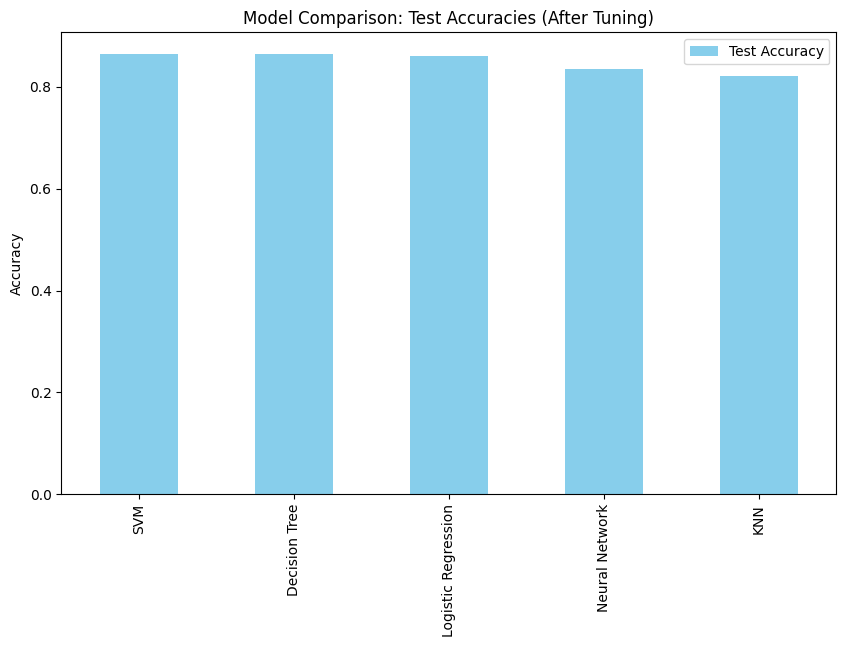

In [101]:
models = {
    "Decision Tree": dt_best,
    "KNN": knn_best,
    "Logistic Regression": log_best,
    "Neural Network": nn_best,
    "SVM": svm_best
}

results = {}
for name, model in models.items():
    acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = acc

# Display test accuracies
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Test Accuracy'])
print("\nModel Comparison (After Hyperparameter Tuning):")
print(results_df)

# Visualize results
import matplotlib.pyplot as plt

results_df.sort_values(by='Test Accuracy', ascending=False).plot(kind='bar', color='skyblue', figsize=(10, 6))
plt.title('Model Comparison: Test Accuracies (After Tuning)')
plt.ylabel('Accuracy')
plt.show()


#### **Comparing Model Performance(Confusion Matrics)** 

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Function to plot confusion matrix
def plot_confusion_matrix(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['LOS', 'NLOS'], yticklabels=['LOS', 'NLOS'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    return cm



Decision Tree Results:
Training Accuracy: 0.8682
Test Accuracy: 0.8633
Overfitting detected: False

Accuracy by Environment:
Environment
Bedroom                      0.86
Boiler room                  0.88
Kitchen with a living room   0.85
Office 1                     0.87
Office 2                     0.86
Small Apartment              0.86
Small Workshop               0.86
dtype: float64


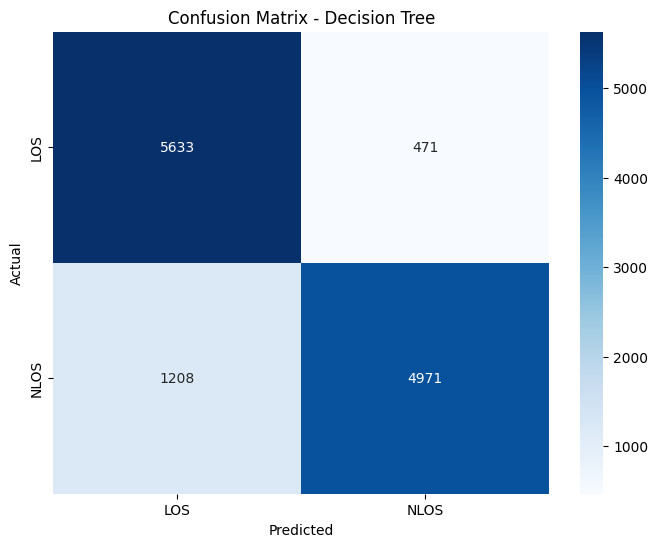


KNN Results:
Training Accuracy: 0.8518
Test Accuracy: 0.8215
Overfitting detected: False

Accuracy by Environment:
Environment
Bedroom                      0.83
Boiler room                  0.84
Kitchen with a living room   0.81
Office 1                     0.82
Office 2                     0.81
Small Apartment              0.83
Small Workshop               0.82
dtype: float64


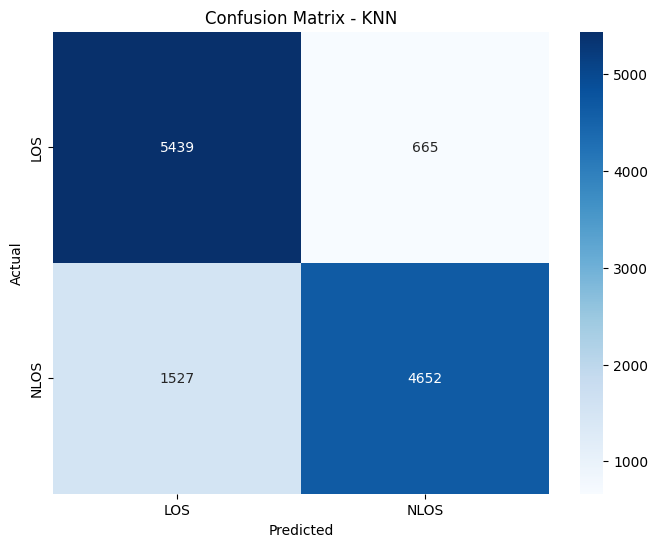


Logistic Regression Results:
Training Accuracy: 0.8607
Test Accuracy: 0.8596
Overfitting detected: False

Accuracy by Environment:
Environment
Bedroom                      0.86
Boiler room                  0.87
Kitchen with a living room   0.85
Office 1                     0.86
Office 2                     0.85
Small Apartment              0.86
Small Workshop               0.85
dtype: float64


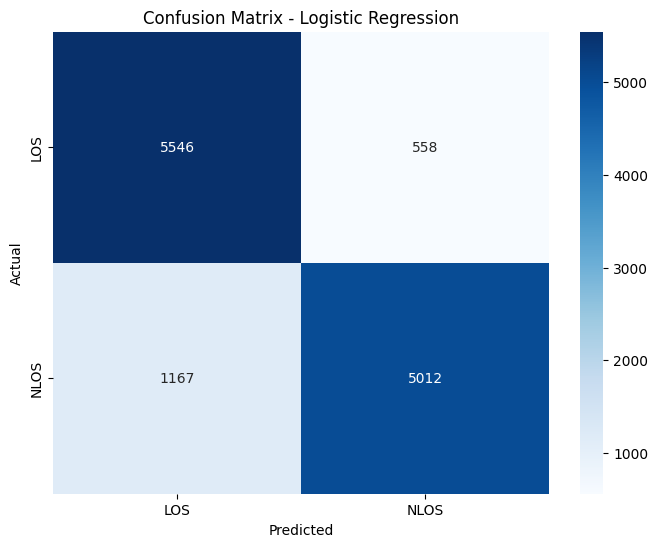


Logistic Regression Results:
Training Accuracy: 0.8607
Test Accuracy: 0.8596
Overfitting detected: False

Accuracy by Environment:
Environment
Bedroom                      0.86
Boiler room                  0.87
Kitchen with a living room   0.85
Office 1                     0.86
Office 2                     0.85
Small Apartment              0.86
Small Workshop               0.85
dtype: float64


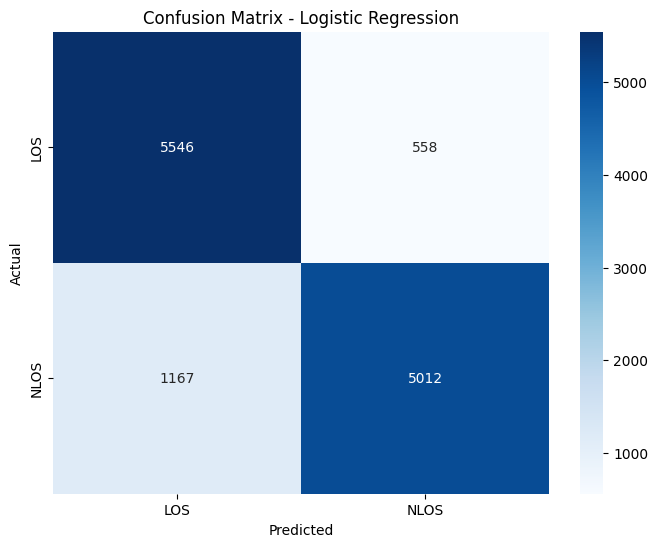


Neural Network Results:
Training Accuracy: 0.8366
Test Accuracy: 0.8345
Overfitting detected: False

Accuracy by Environment:
Environment
Bedroom                      0.83
Boiler room                  0.84
Kitchen with a living room   0.82
Office 1                     0.83
Office 2                     0.83
Small Apartment              0.85
Small Workshop               0.83
dtype: float64


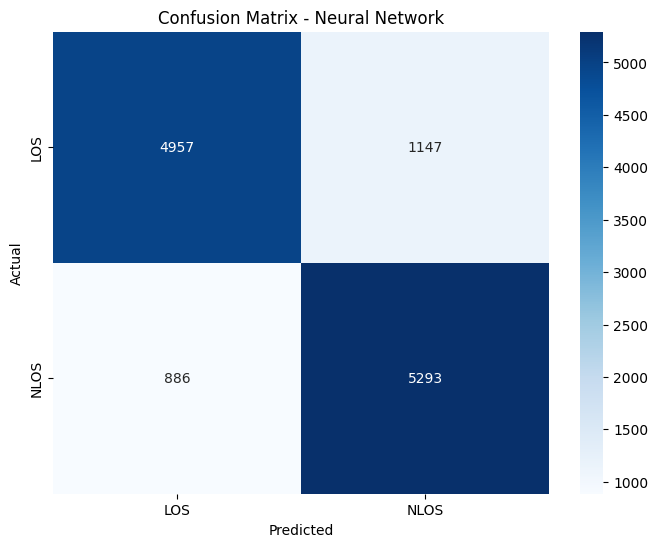


SVM Results:
Training Accuracy: 0.8645
Test Accuracy: 0.8637
Overfitting detected: False

Accuracy by Environment:
Environment
Bedroom                      0.86
Boiler room                  0.88
Kitchen with a living room   0.85
Office 1                     0.87
Office 2                     0.86
Small Apartment              0.87
Small Workshop               0.86
dtype: float64


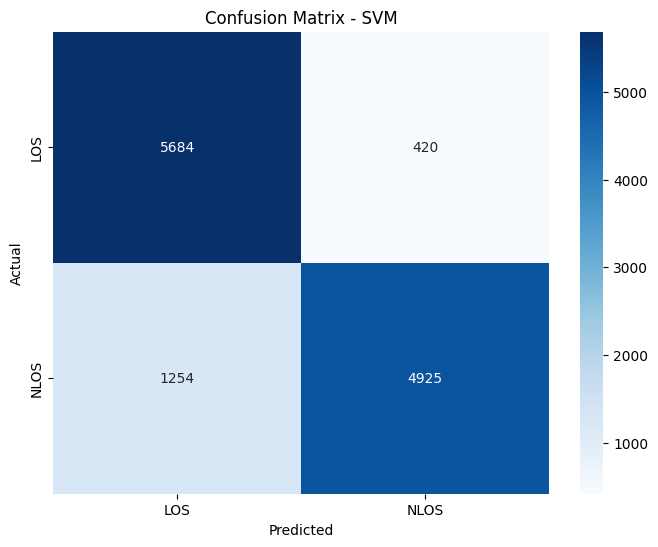

In [103]:
print("\nDecision Tree Results:")
check_overfitting(dt_best, X_train, y_train, X_test, y_test)
env_accuracy(dt_best, X_test, y_test)

# Plot confusion matrix
dt_cm = plot_confusion_matrix(dt_best, X_test, y_test, "Decision Tree")

print("\nKNN Results:")
check_overfitting(knn_best, X_train, y_train, X_test, y_test)
env_accuracy(knn_best, X_test, y_test)

# Plot confusion matrix
knn_cm = plot_confusion_matrix(knn_best, X_test, y_test, "KNN")

print("\nLogistic Regression Results:")
check_overfitting(log_best, X_train, y_train, X_test, y_test)
env_accuracy(log_best, X_test, y_test)

# Plot confusion matrix
log_cm = plot_confusion_matrix(log_best, X_test, y_test, "Logistic Regression")

print("\nLogistic Regression Results:")
check_overfitting(log_best, X_train, y_train, X_test, y_test)
env_accuracy(log_best, X_test, y_test)

# Plot confusion matrix
log_cm = plot_confusion_matrix(log_best, X_test, y_test, "Logistic Regression")

print("\nNeural Network Results:")
check_overfitting(nn_best, X_train, y_train, X_test, y_test)
env_accuracy(nn_best, X_test, y_test)

# Plot confusion matrix
nn_cm = plot_confusion_matrix(nn_best, X_test, y_test, "Neural Network")

print("\nSVM Results:")
check_overfitting(svm_best, X_train, y_train, X_test, y_test)
env_accuracy(svm_best, X_test, y_test)

# Plot confusion matrix
svm_cm = plot_confusion_matrix(svm_best, X_test, y_test, "SVM")


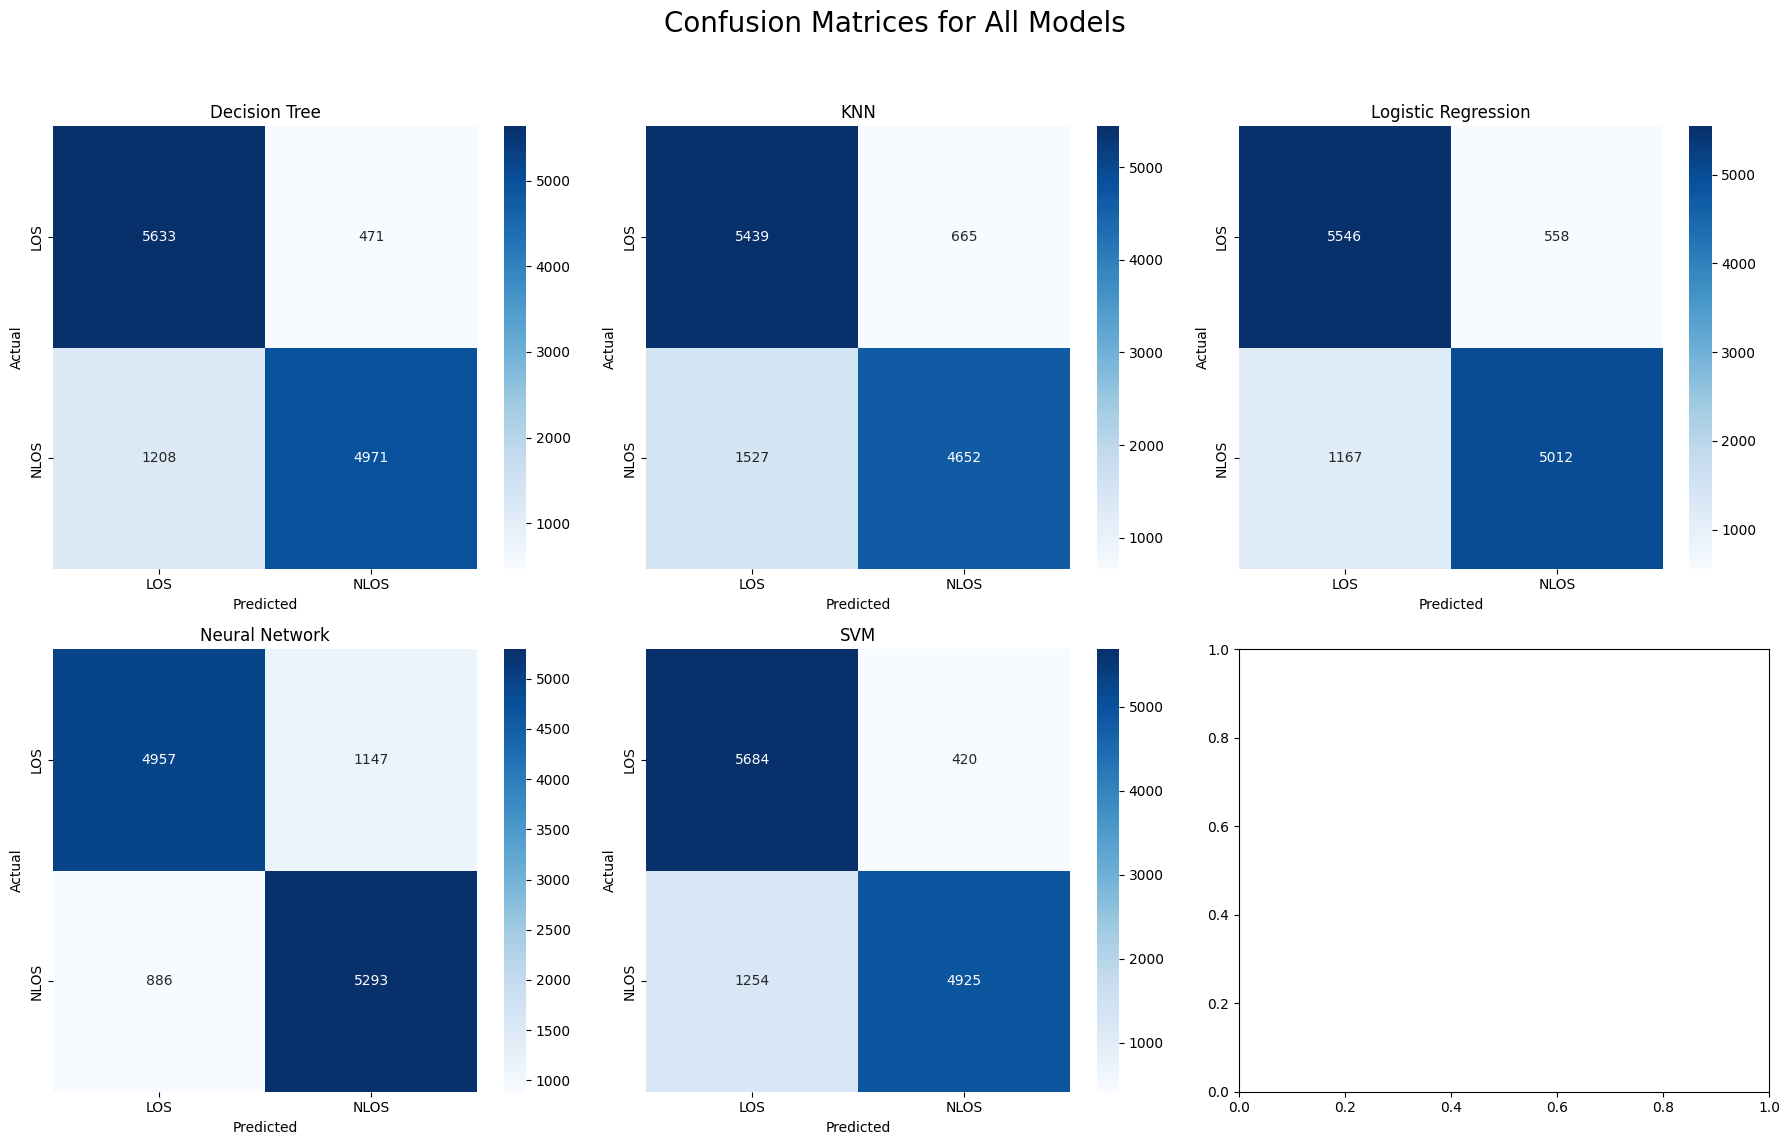

In [104]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Confusion Matrices for All Models', fontsize=20)

# Plot confusion matrices
models = [("Decision Tree", dt_cm), ("KNN", knn_cm), ("Logistic Regression", log_cm),
          ("Neural Network", nn_cm), ("SVM", svm_cm)]
model_names = [model[0] for model in models]
cm_values = [model[1] for model in models]

for ax, (name, cm) in zip(axes.flatten(), models):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['LOS', 'NLOS'], yticklabels=['LOS', 'NLOS'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [105]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Separate LOS and NLOS data
los_data = cleaned_data_top[cleaned_data_top['NLOS'] == 0]
nlos_data = cleaned_data_top[cleaned_data_top['NLOS'] == 1]

# Features (X) and target (y = RANGE) for both LOS and NLOS
X_los = los_data.drop(columns=['RANGE', 'NLOS', 'Environment'])
y_los = los_data['RANGE']

X_nlos = nlos_data.drop(columns=['RANGE', 'NLOS', 'Environment'])
y_nlos = nlos_data['RANGE']

# Train-test split (70-30)
X_los_train, X_los_test, y_los_train, y_los_test = train_test_split(X_los, y_los, test_size=0.3, random_state=42)
X_nlos_train, X_nlos_test, y_nlos_train, y_nlos_test = train_test_split(X_nlos, y_nlos, test_size=0.3, random_state=42)

print("LOS training set size:", X_los_train.shape)
print("NLOS training set size:", X_nlos_train.shape)

LOS training set size: (14320, 18)
NLOS training set size: (14338, 18)


In [109]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor": SVR(),
    "Neural Network": MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Store results
results = []

# Train and test each model (LOS)
for name, model in models.items():
    model.fit(X_los_train, y_los_train)
    y_pred = model.predict(X_los_test)
    
    rmse = np.sqrt(mean_squared_error(y_los_test, y_pred))
    r2 = r2_score(y_los_test, y_pred)
    
    results.append({"Model": name, "RMSE": rmse, "R²": r2, "Path": "LOS"})

# Train and test each model (NLOS)
for name, model in models.items():
    model.fit(X_nlos_train, y_nlos_train)
    y_pred = model.predict(X_nlos_test)
    
    rmse = np.sqrt(mean_squared_error(y_nlos_test, y_pred))
    r2 = r2_score(y_nlos_test, y_pred)
    
    results.append({"Model": name, "RMSE": rmse, "R²": r2, "Path": "NLOS"})

# Results dataframe
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)



Model Comparison:
                      Model  RMSE      R²  Path
0         Linear Regression  1.08    0.57   LOS
1             Random Forest  0.99    0.64   LOS
2  Support Vector Regressor  1.26    0.41   LOS
3            Neural Network 27.51 -279.80   LOS
4         Gradient Boosting  1.01    0.62   LOS
5         Linear Regression  1.91    0.38  NLOS
6             Random Forest  1.63    0.55  NLOS
7  Support Vector Regressor  2.11    0.24  NLOS
8            Neural Network 11.54  -21.71  NLOS
9         Gradient Boosting  1.68    0.52  NLOS


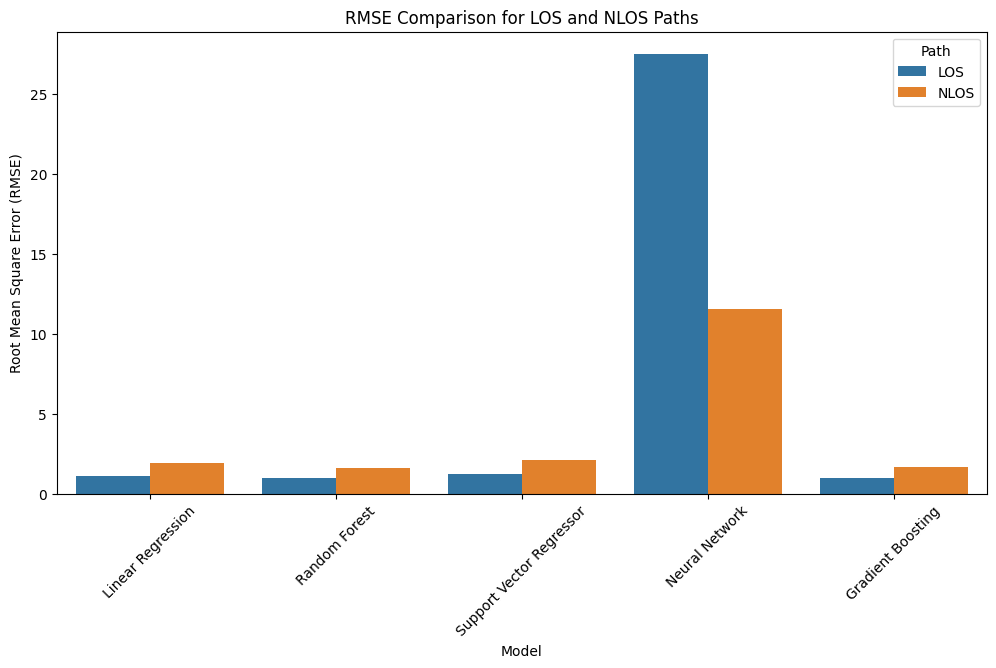

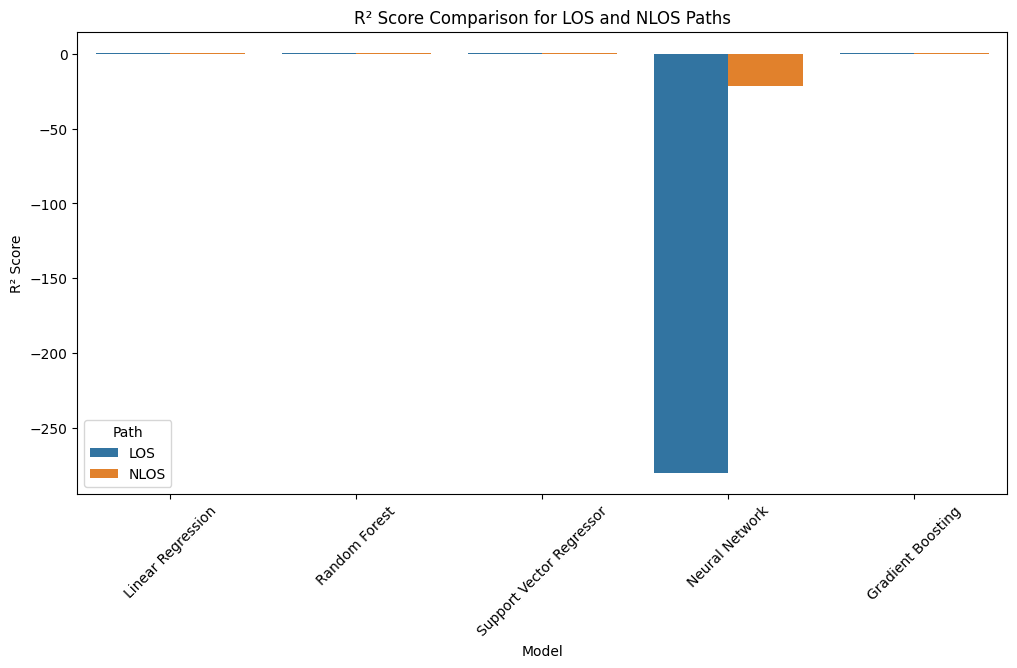

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot RMSE and R² scores for comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='Model', y='RMSE', hue='Path')
plt.title('RMSE Comparison for LOS and NLOS Paths')
plt.ylabel('Root Mean Square Error (RMSE)')
plt.xticks(rotation=45)
plt.legend(title='Path')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='Model', y='R²', hue='Path')
plt.title('R² Score Comparison for LOS and NLOS Paths')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.legend(title='Path')
plt.show()


In [111]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Separate LOS and NLOS data
los_data = cleaned_data_top[cleaned_data_top['NLOS'] == 0]
nlos_data = cleaned_data_top[cleaned_data_top['NLOS'] == 1]

# Features (X) and target (y = RANGE)
X_los = los_data.drop(columns=['RANGE', 'NLOS', 'Environment'])
y_los = los_data['RANGE']

X_nlos = nlos_data.drop(columns=['RANGE', 'NLOS', 'Environment'])
y_nlos = nlos_data['RANGE']

# Train-test split (70-30)
X_los_train, X_los_test, y_los_train, y_los_test = train_test_split(X_los, y_los, test_size=0.3, random_state=42)
X_nlos_train, X_nlos_test, y_nlos_train, y_nlos_test = train_test_split(X_nlos, y_nlos, test_size=0.3, random_state=42)

print("LOS training set size:", X_los_train.shape)
print("NLOS training set size:", X_nlos_train.shape)


LOS training set size: (14320, 18)
NLOS training set size: (14338, 18)


In [115]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Function to tune hyperparameters and retrain model
def tune_and_retrain(model, param_grid, X_train, y_train, X_test, y_test):
    random_search = RandomizedSearchCV(
        model, param_grid, n_iter=10, cv=3, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    
    best_model = random_search.best_estimator_  # Get best model
    print("Best Hyperparameters:", random_search.best_params_)
    print(f"Best Cross-validation Score (MSE): {abs(random_search.best_score_):.4f}")
    
    # Retrain best model
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    
    # Evaluate model
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"Test RMSE after tuning: {rmse:.4f}")
    print(f"Test R² Score after tuning: {r2:.4f}")
    
    return best_model, rmse, r2


In [116]:
# Hyperparameter grids
param_grids = {
    "Linear Regression": {},  # No hyperparameters to tune
    
    "Random Forest": {
        "n_estimators": [50, 100, 200, 300],
        "max_depth": [10, 20, 30, None],
        "min_samples_split": [2, 5, 10]
    },
    
    "Support Vector Regressor": {
        "C": [0.1, 1, 10],
        "kernel": ['rbf'],
        "epsilon": [0.01, 0.1, 1]
    },
    
    "Neural Network": {
        "hidden_layer_sizes": [(50,), (100,), (100, 50)],
        "alpha": [0.0001, 0.001, 0.01],
        "max_iter": [500, 1000, 1500]
    },
    
    "Gradient Boosting": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 10]
    }
}


In [117]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "Neural Network": MLPRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Store results
los_results = []

for name, model in models.items():
    print(f"Tuning {name} for LOS path...")
    best_model, rmse, r2 = tune_and_retrain(model, param_grids[name], X_los_train, y_los_train, X_los_test, y_los_test)
    los_results.append({"Model": name, "RMSE": rmse, "R²": r2, "Path": "LOS"})

los_results_df = pd.DataFrame(los_results)
print("\nLOS Path Model Comparison (After Tuning):")
print(los_results_df)


Tuning Linear Regression for LOS path...


C:\Users\Leong Jing Feng\anaconda3\envs\DA_Project\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Hyperparameters: {}
Best Cross-validation Score (MSE): 1.1302
Test RMSE after tuning: 1.0807
Test R² Score after tuning: 0.5668
Tuning Random Forest for LOS path...
Best Hyperparameters: {'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 20}
Best Cross-validation Score (MSE): 0.9553
Test RMSE after tuning: 0.9877
Test R² Score after tuning: 0.6381
Tuning Support Vector Regressor for LOS path...


C:\Users\Leong Jing Feng\anaconda3\envs\DA_Project\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Hyperparameters: {'kernel': 'rbf', 'epsilon': 0.1, 'C': 10}
Best Cross-validation Score (MSE): 1.3524
Test RMSE after tuning: 1.1580
Test R² Score after tuning: 0.5026
Tuning Neural Network for LOS path...
Best Hyperparameters: {'max_iter': 1000, 'hidden_layer_sizes': (100,), 'alpha': 0.001}
Best Cross-validation Score (MSE): 179.0862
Test RMSE after tuning: 19.3609
Test R² Score after tuning: -138.0487
Tuning Gradient Boosting for LOS path...
Best Hyperparameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
Best Cross-validation Score (MSE): 0.9677
Test RMSE after tuning: 0.9889
Test R² Score after tuning: 0.6372

LOS Path Model Comparison (After Tuning):
                      Model  RMSE      R² Path
0         Linear Regression  1.08    0.57  LOS
1             Random Forest  0.99    0.64  LOS
2  Support Vector Regressor  1.16    0.50  LOS
3            Neural Network 19.36 -138.05  LOS
4         Gradient Boosting  0.99    0.64  LOS


In [118]:
# Store results
nlos_results = []

for name, model in models.items():
    print(f"Tuning {name} for NLOS path...")
    best_model, rmse, r2 = tune_and_retrain(model, param_grids[name], X_nlos_train, y_nlos_train, X_nlos_test, y_nlos_test)
    nlos_results.append({"Model": name, "RMSE": rmse, "R²": r2, "Path": "NLOS"})

nlos_results_df = pd.DataFrame(nlos_results)
print("\nNLOS Path Model Comparison (After Tuning):")
print(nlos_results_df)


Tuning Linear Regression for NLOS path...
Best Hyperparameters: {}
Best Cross-validation Score (MSE): 3.6314
Test RMSE after tuning: 1.9094
Test R² Score after tuning: 0.3786
Tuning Random Forest for NLOS path...


C:\Users\Leong Jing Feng\anaconda3\envs\DA_Project\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Hyperparameters: {'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 20}
Best Cross-validation Score (MSE): 2.6700
Test RMSE after tuning: 1.6204
Test R² Score after tuning: 0.5524
Tuning Support Vector Regressor for NLOS path...


C:\Users\Leong Jing Feng\anaconda3\envs\DA_Project\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Hyperparameters: {'kernel': 'rbf', 'epsilon': 1, 'C': 10}
Best Cross-validation Score (MSE): 4.2252
Test RMSE after tuning: 2.0311
Test R² Score after tuning: 0.2969
Tuning Neural Network for NLOS path...
Best Hyperparameters: {'max_iter': 500, 'hidden_layer_sizes': (50,), 'alpha': 0.0001}
Best Cross-validation Score (MSE): 28.7127
Test RMSE after tuning: 8.4912
Test R² Score after tuning: -11.2891
Tuning Gradient Boosting for NLOS path...
Best Hyperparameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
Best Cross-validation Score (MSE): 2.7336
Test RMSE after tuning: 1.6391
Test R² Score after tuning: 0.5421

NLOS Path Model Comparison (After Tuning):
                      Model  RMSE     R²  Path
0         Linear Regression  1.91   0.38  NLOS
1             Random Forest  1.62   0.55  NLOS
2  Support Vector Regressor  2.03   0.30  NLOS
3            Neural Network  8.49 -11.29  NLOS
4         Gradient Boosting  1.64   0.54  NLOS


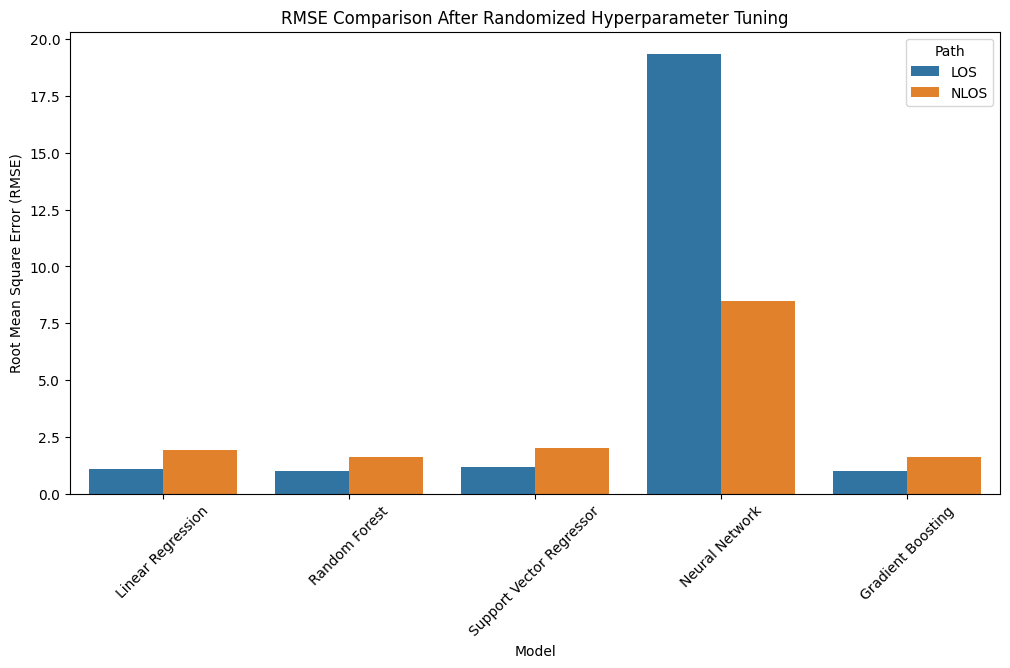

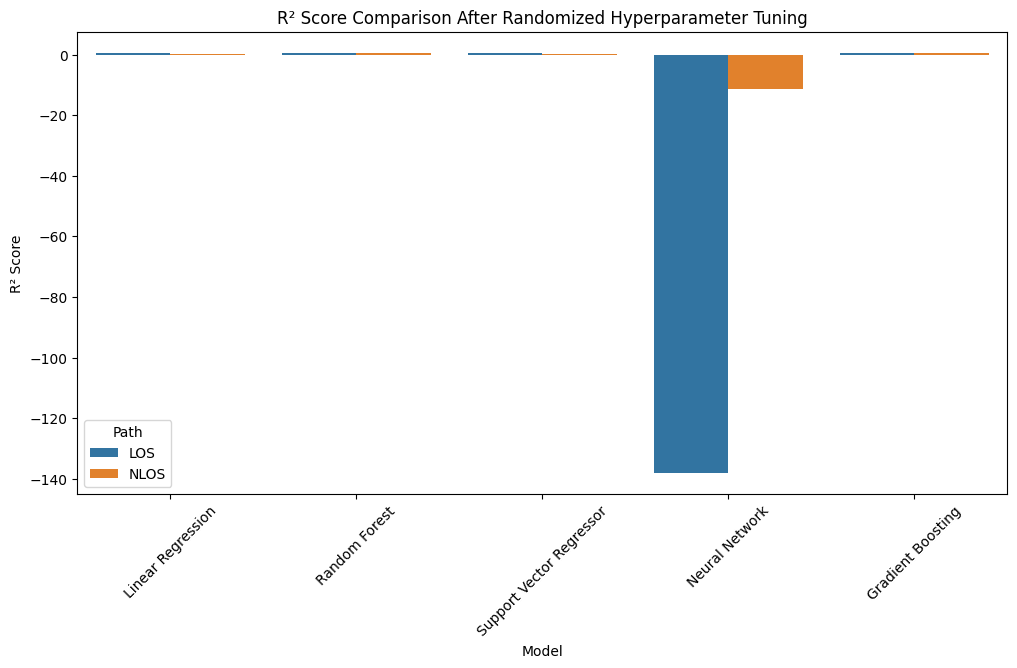

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine results
combined_results = pd.concat([los_results_df, nlos_results_df])

# Plot RMSE
plt.figure(figsize=(12, 6))
sns.barplot(data=combined_results, x='Model', y='RMSE', hue='Path')
plt.title('RMSE Comparison After Randomized Hyperparameter Tuning')
plt.ylabel('Root Mean Square Error (RMSE)')
plt.xticks(rotation=45)
plt.legend(title='Path')
plt.show()

# Plot R² scores
plt.figure(figsize=(12, 6))
sns.barplot(data=combined_results, x='Model', y='R²', hue='Path')
plt.title('R² Score Comparison After Randomized Hyperparameter Tuning')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.legend(title='Path')
plt.show()
